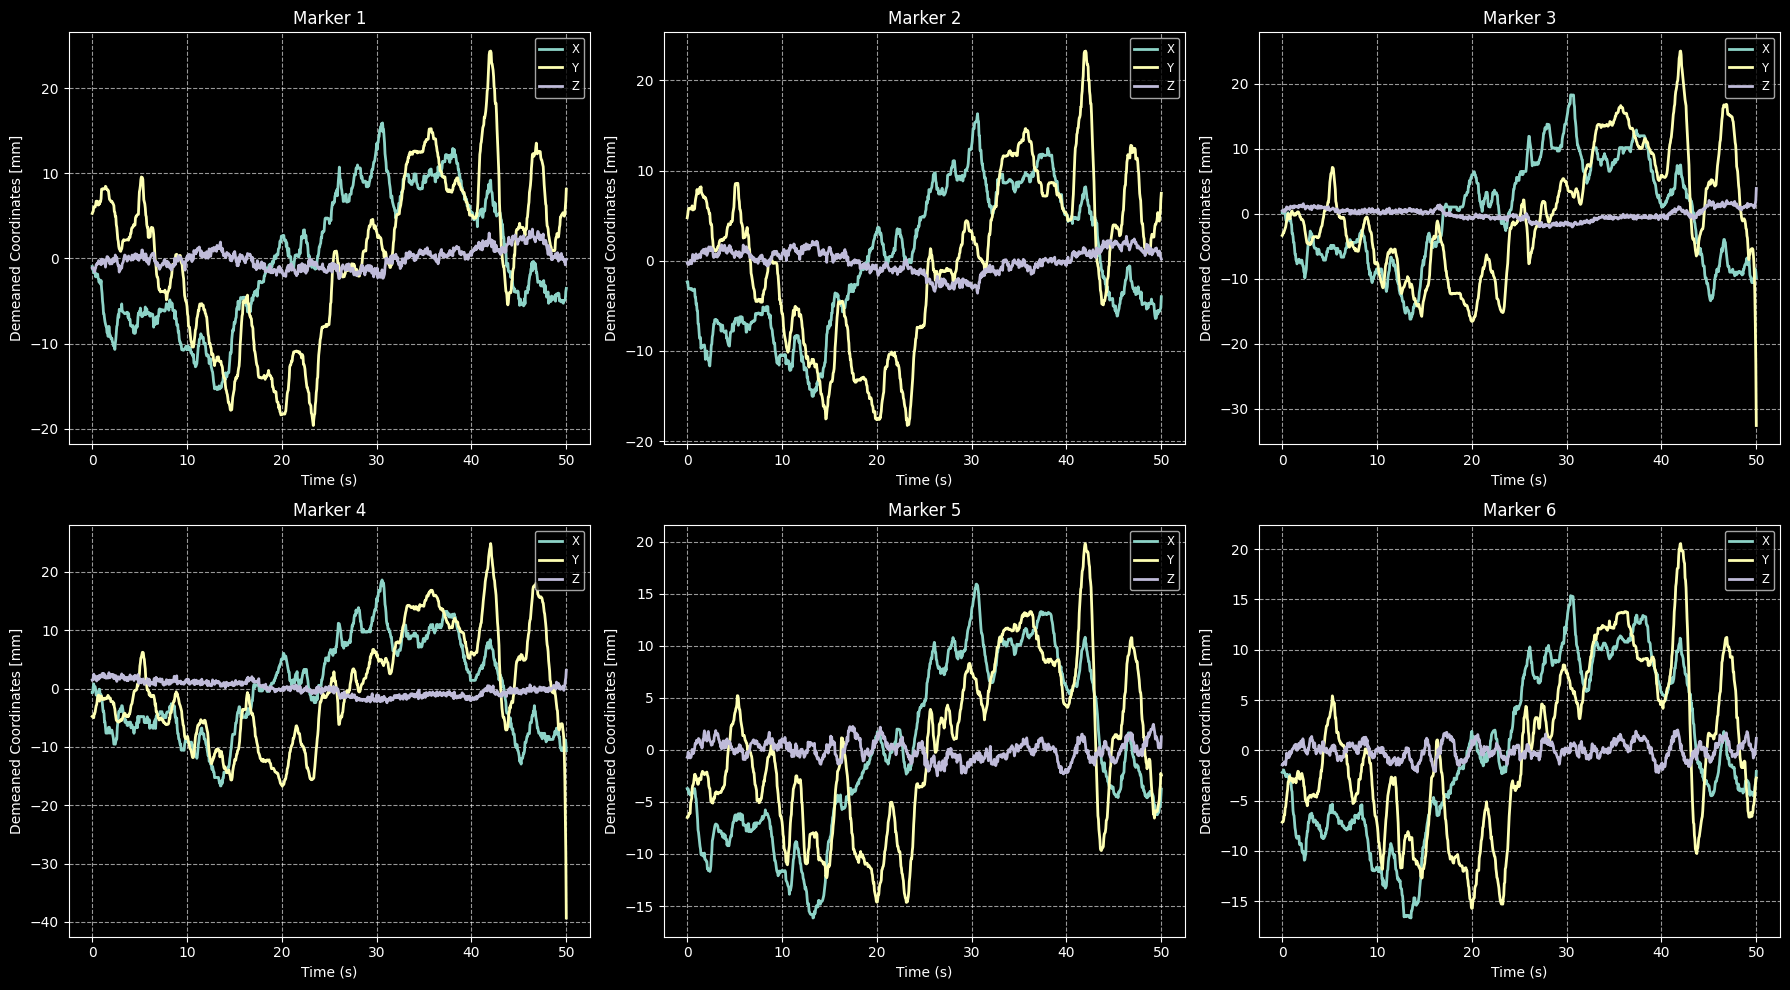

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/jose3/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/jose3/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# PLOTTING FUNCTION
# -------------------------
def plot_to_ax(ax, data, marker_pos):
    num_points = data.shape[0]
    t = np.linspace(0, 50, num_points)  # time axis (0–60 sec)

    ax.plot(t, data[:, 0], label='X', linewidth=2)
    ax.plot(t, data[:, 1], label='Y', linewidth=2)
    ax.plot(t, data[:, 2], label='Z', linewidth=2)

    ax.set_ylabel('Demeaned Coordinates [mm]')
    ax.set_xlabel('Time (s)')
    ax.set_title(marker_pos)
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)


# -------------------------
# LOAD DATA
# -------------------------

raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True) # optional: cut beggining and end frames

marker1 = raw_df[['pt1_x', 'pt1_y', 'pt1_z']]
marker2 = raw_df[['pt2_x', 'pt2_y', 'pt2_z']]
marker3 = raw_df[['pt3_x', 'pt3_y', 'pt3_z']]
marker4 = raw_df[['pt4_x', 'pt4_y', 'pt4_z']]
marker5 = raw_df[['pt5_x', 'pt5_y', 'pt5_z']]
marker6 = raw_df[['pt6_x', 'pt6_y', 'pt6_z']]

markers = [
    (marker1, 'Marker 1', 'pt1'),
    (marker2, 'Marker 2', 'pt2'),
    (marker3, 'Marker 3', 'pt3'),
    (marker4, 'Marker 4', 'pt4'),
    (marker5, 'Marker 5', 'pt5'),
    (marker6, 'Marker 6', 'pt6')
]

# -------------------------
# CREATE SUBPLOTS (2 rows, 3 columns for 6 markers)
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (df, name, prefix) in zip(axes, markers):
    x = df[f'{prefix}_x']
    y = df[f'{prefix}_y']
    z = df[f'{prefix}_z']

    x_norm = x - x.mean()
    y_norm = y - y.mean()
    z_norm = z - z.mean()

    data = np.vstack((x_norm, y_norm, z_norm)).T

    plot_to_ax(ax, data, name)

plt.tight_layout()
save_path = os.path.join(output_folder, 'markers_normalized.png')
plt.savefig(save_path, dpi=200)
plt.show()

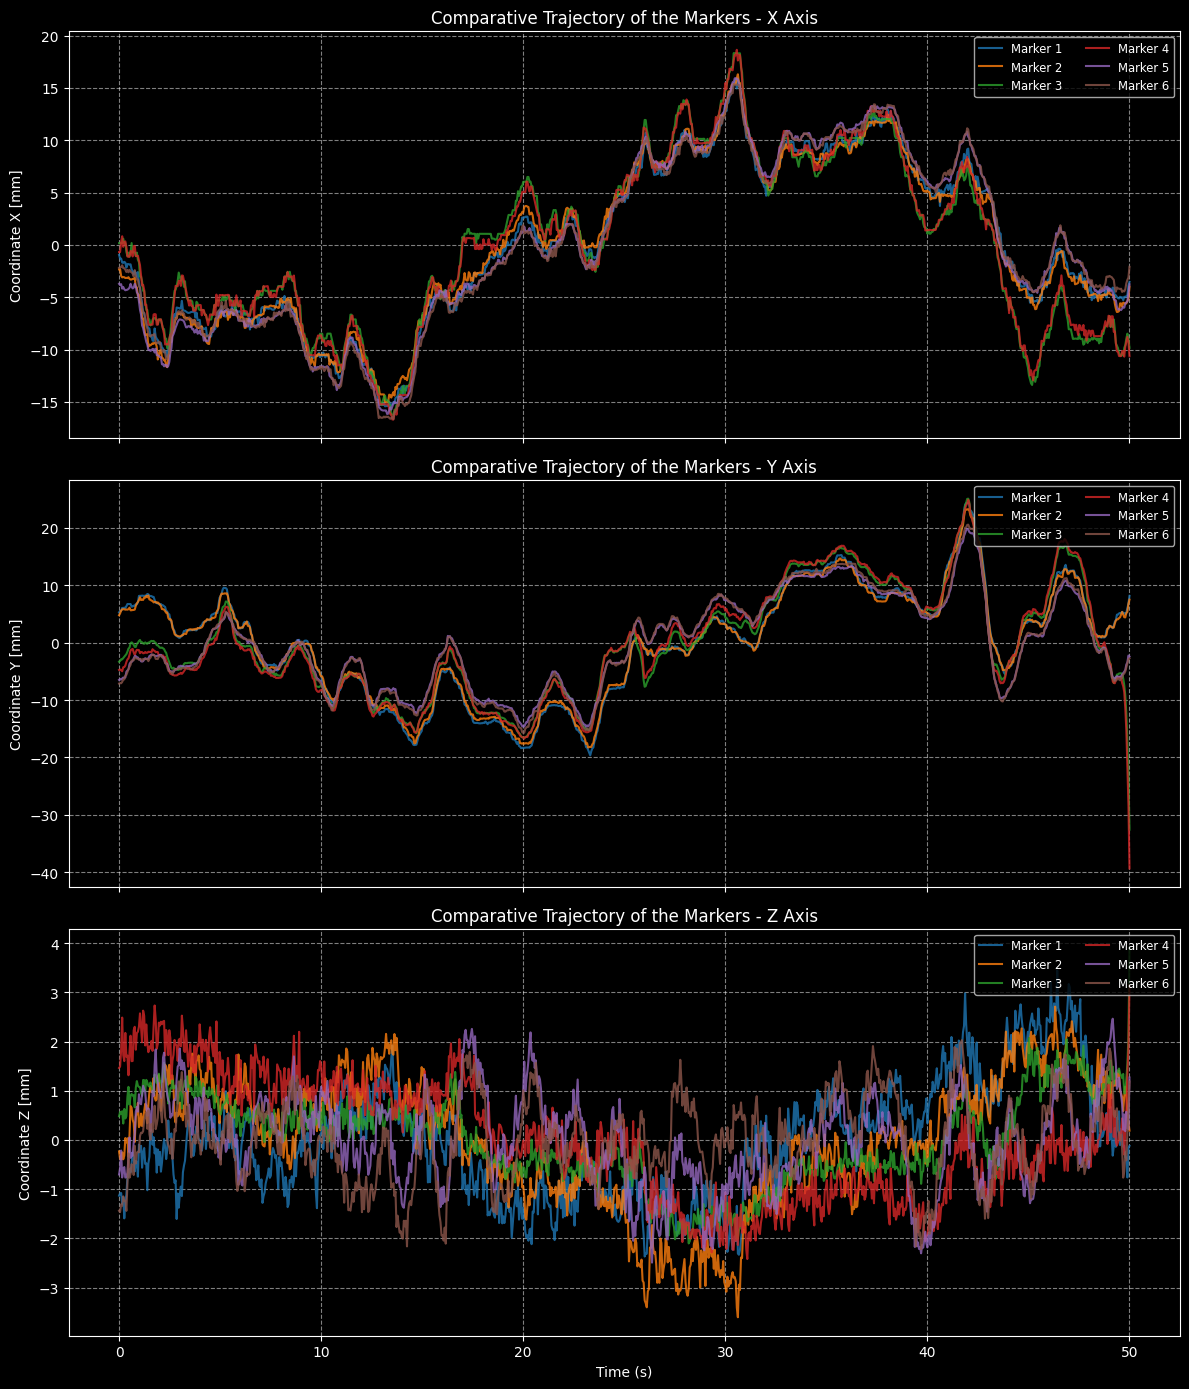

In [68]:


import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/jose3/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/jose3/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(0, 50, num_points)

marker_prefixes = ["pt1", "pt2", "pt3", "pt4", "pt5", "pt6"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# -------------------------
# CREATE SUBPLOTS
# -------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
axes_names = ["X", "Y", "Z"]

for i, axis_letter in enumerate(["x", "y", "z"]):
    ax = axes[i]

    for j, prefix in enumerate(marker_prefixes):
        coord = raw_df[f"{prefix}_{axis_letter}"]

        # Normalization
        coord_norm = coord - coord.mean()

        ax.plot(
            t,
            coord_norm,
            label=f"Marker {j+1}",
            color=colors[j],
            linewidth=1.5,
            alpha=0.8,
        )

    ax.set_ylabel(f"Coordinate {axes_names[i]} [mm]")
    ax.set_title(
        f"Comparative Trajectory of the Markers - {axes_names[i]} Axis"
    )
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper right", fontsize="small", ncol=2)

axes[-1].set_xlabel("Time (s)")

plt.tight_layout()

save_path = os.path.join(output_folder, "trajectories_comparativa.png")
plt.savefig(save_path, dpi=200)
plt.show()

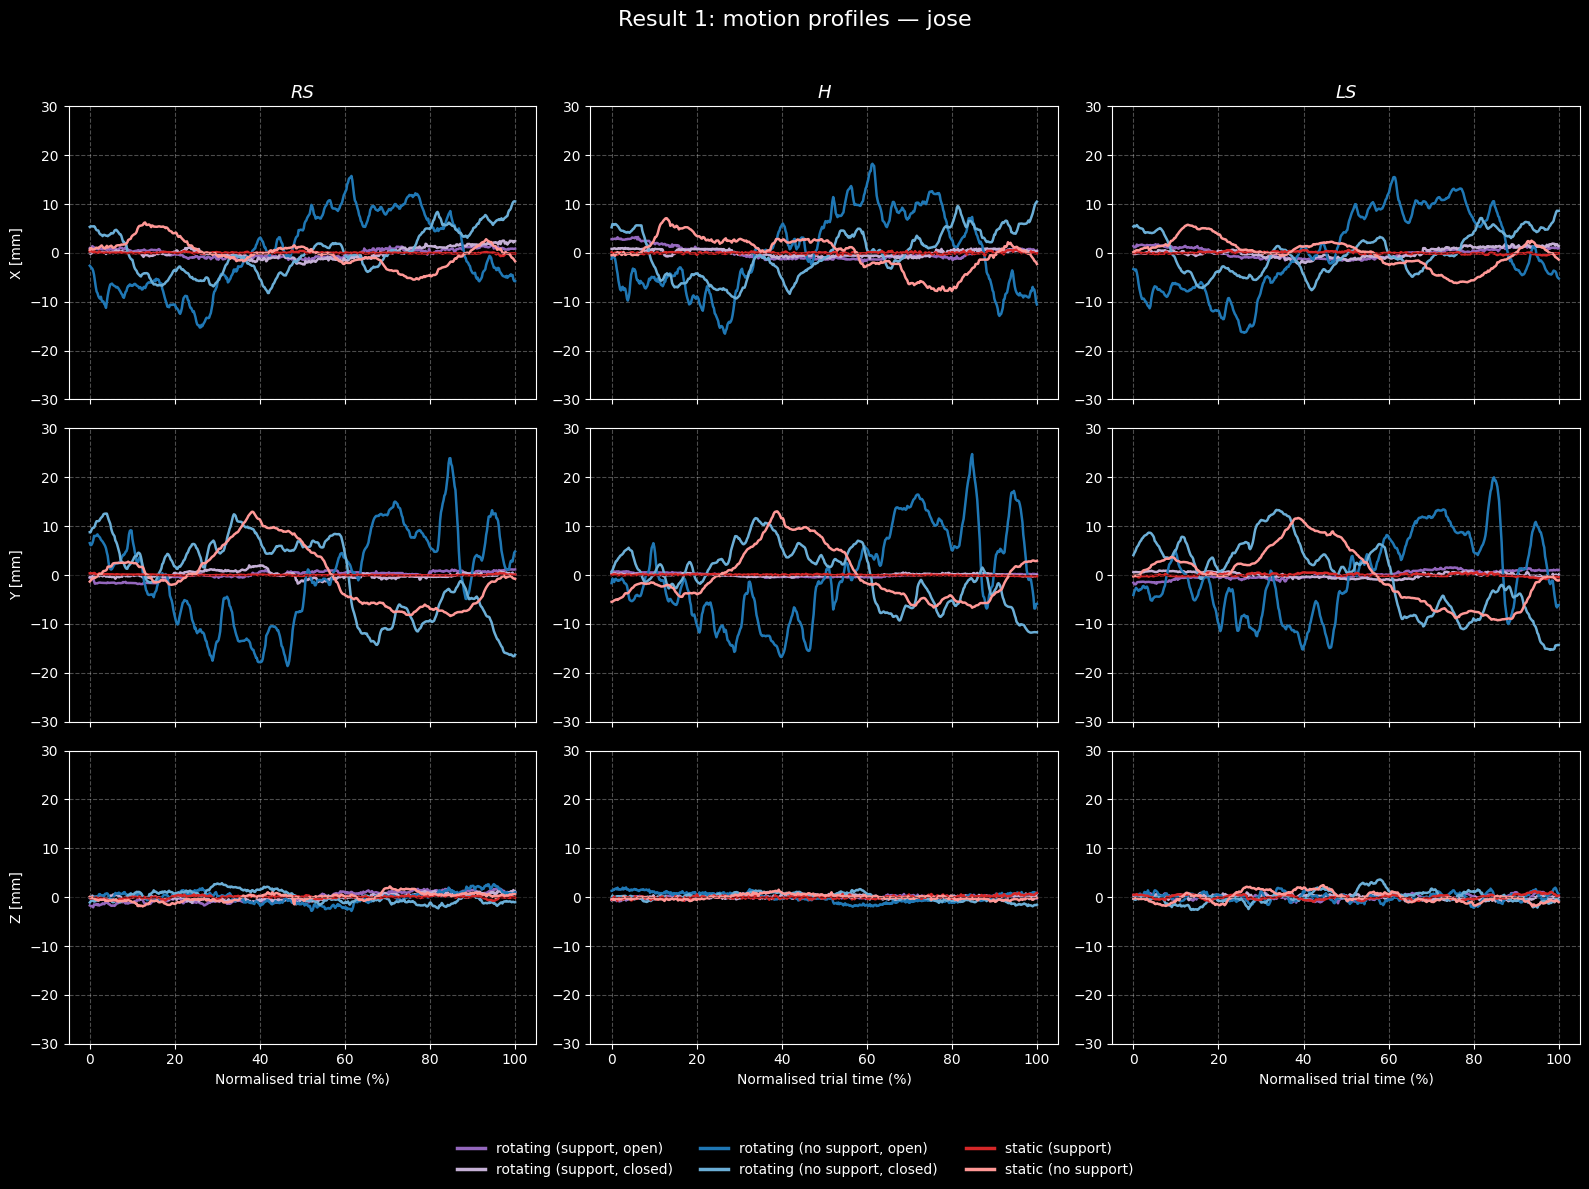

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/motion_profiles_3x3_jose.png


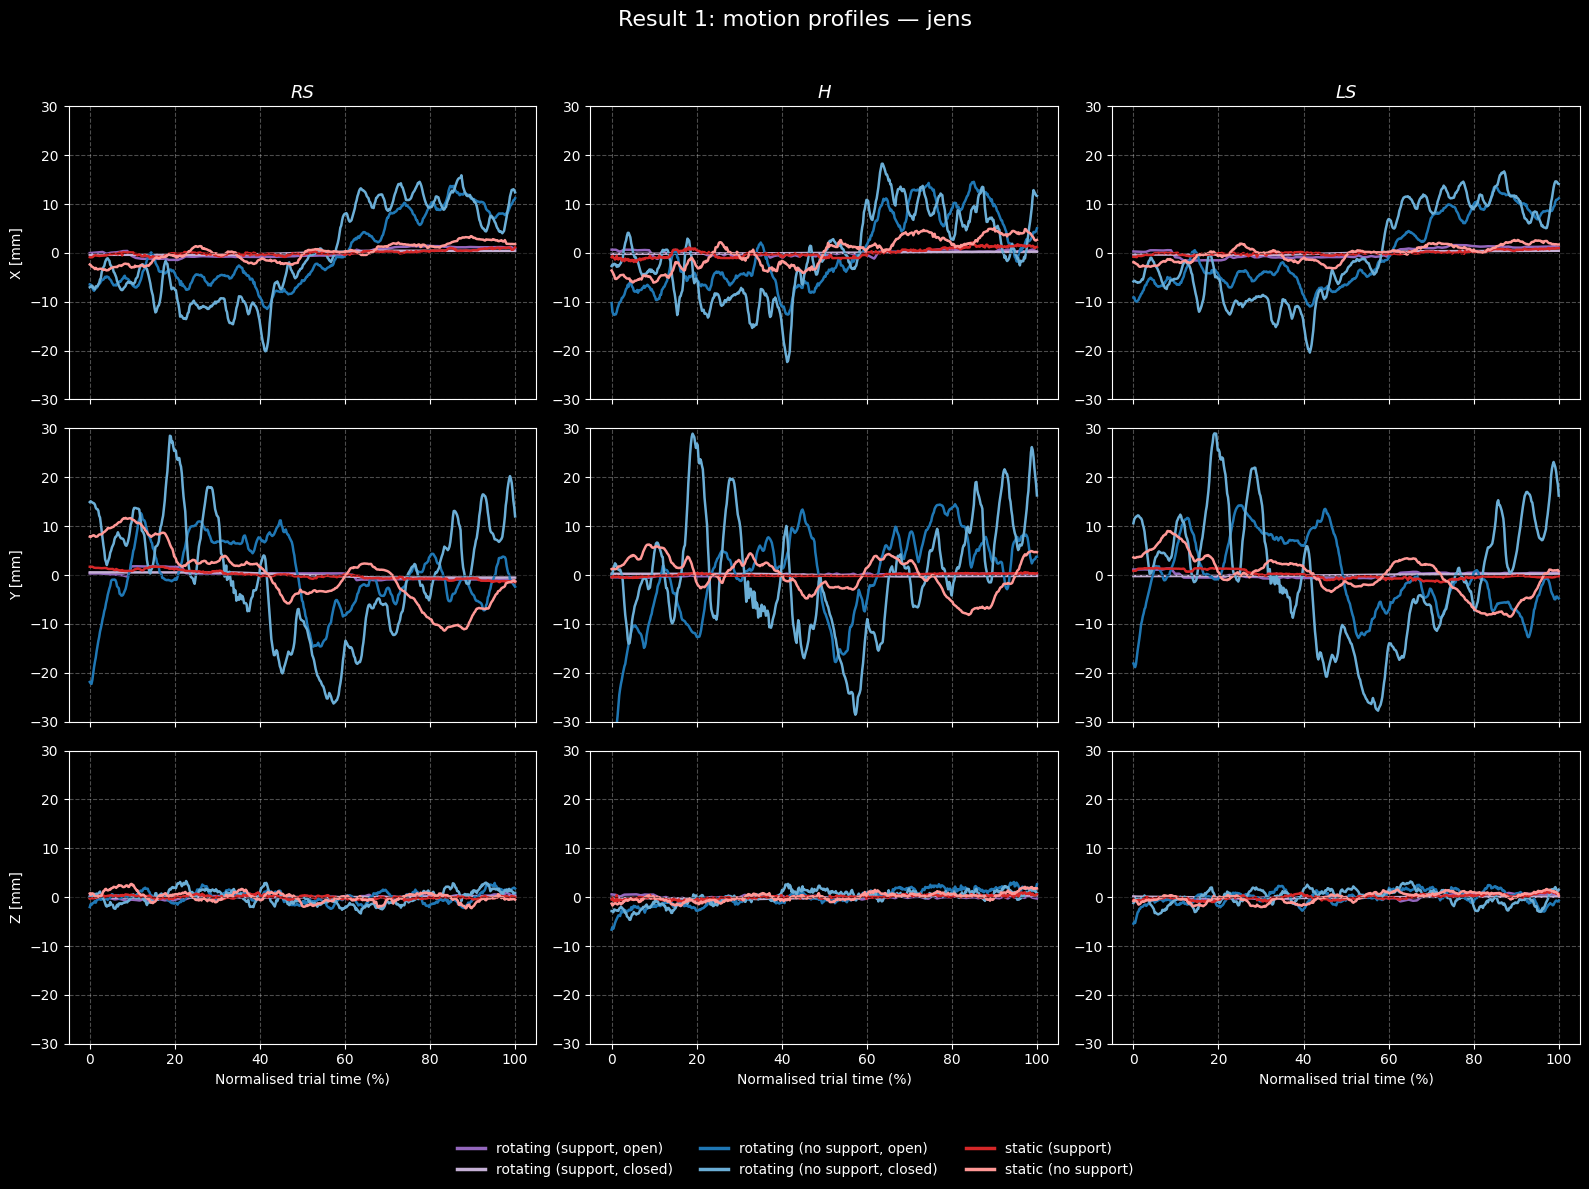

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/motion_profiles_3x3_jens.png


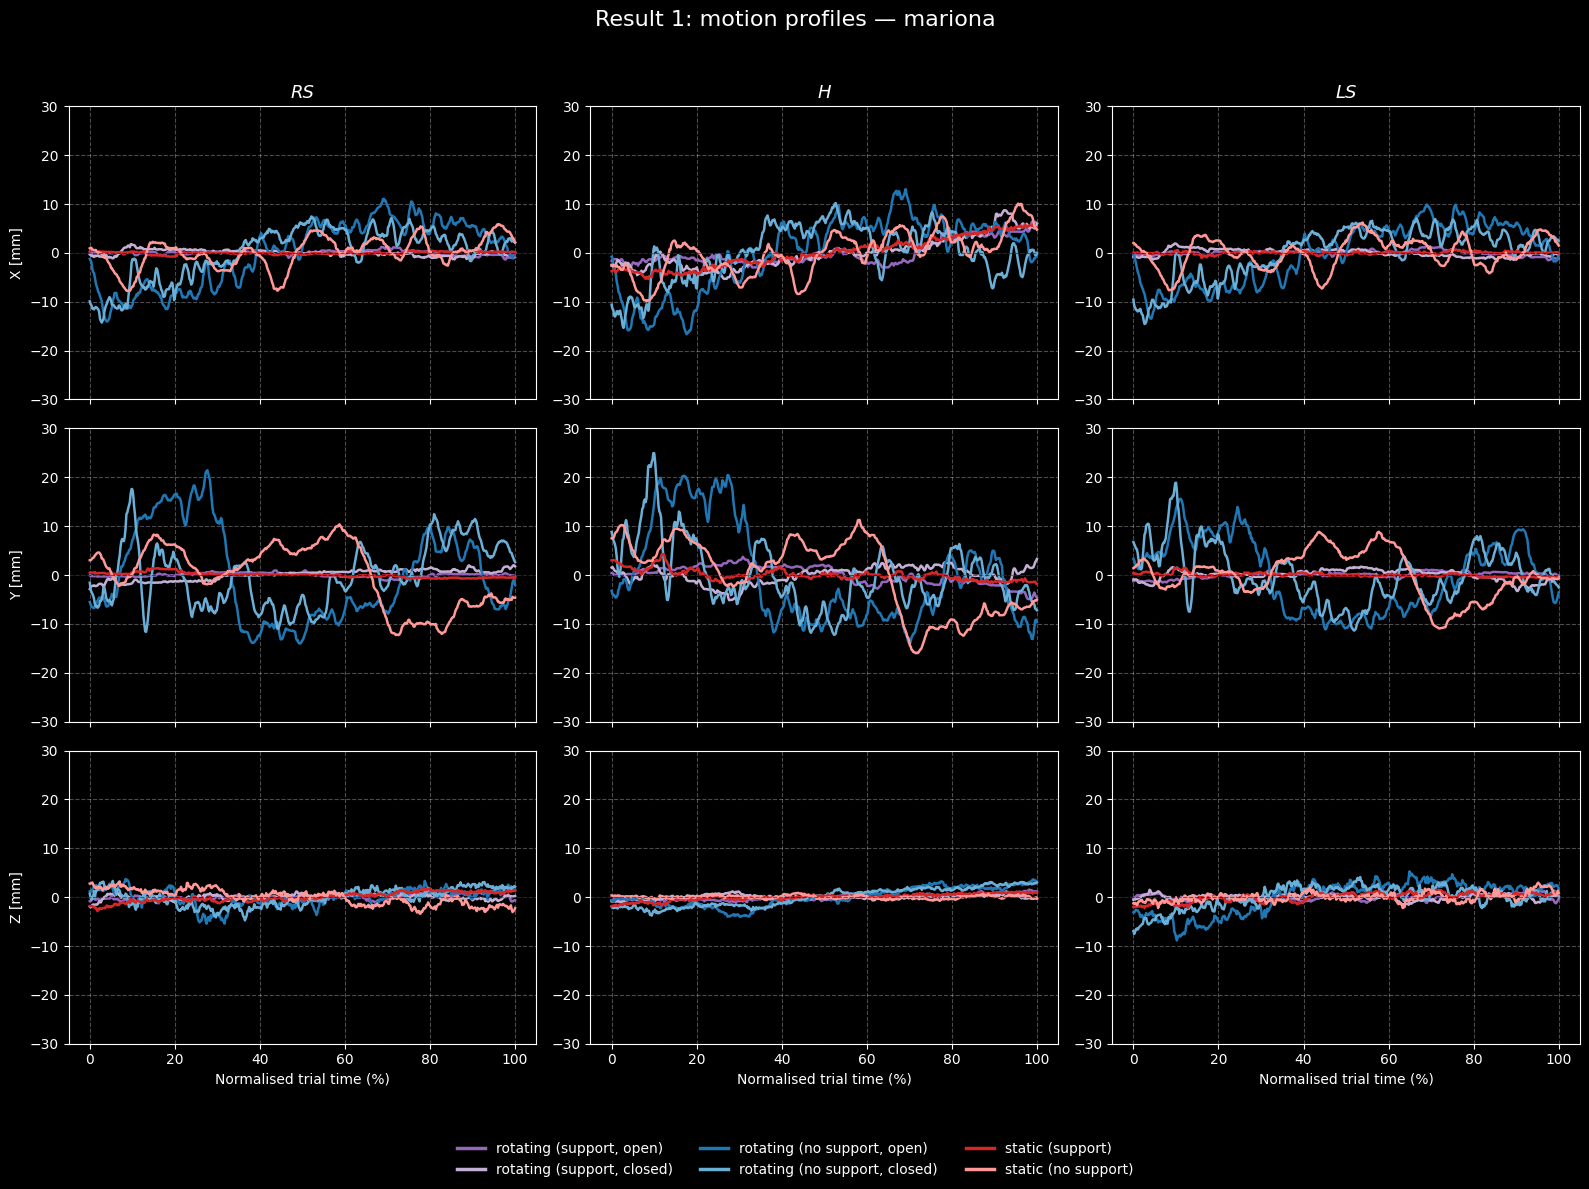

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/motion_profiles_3x3_mariona.png


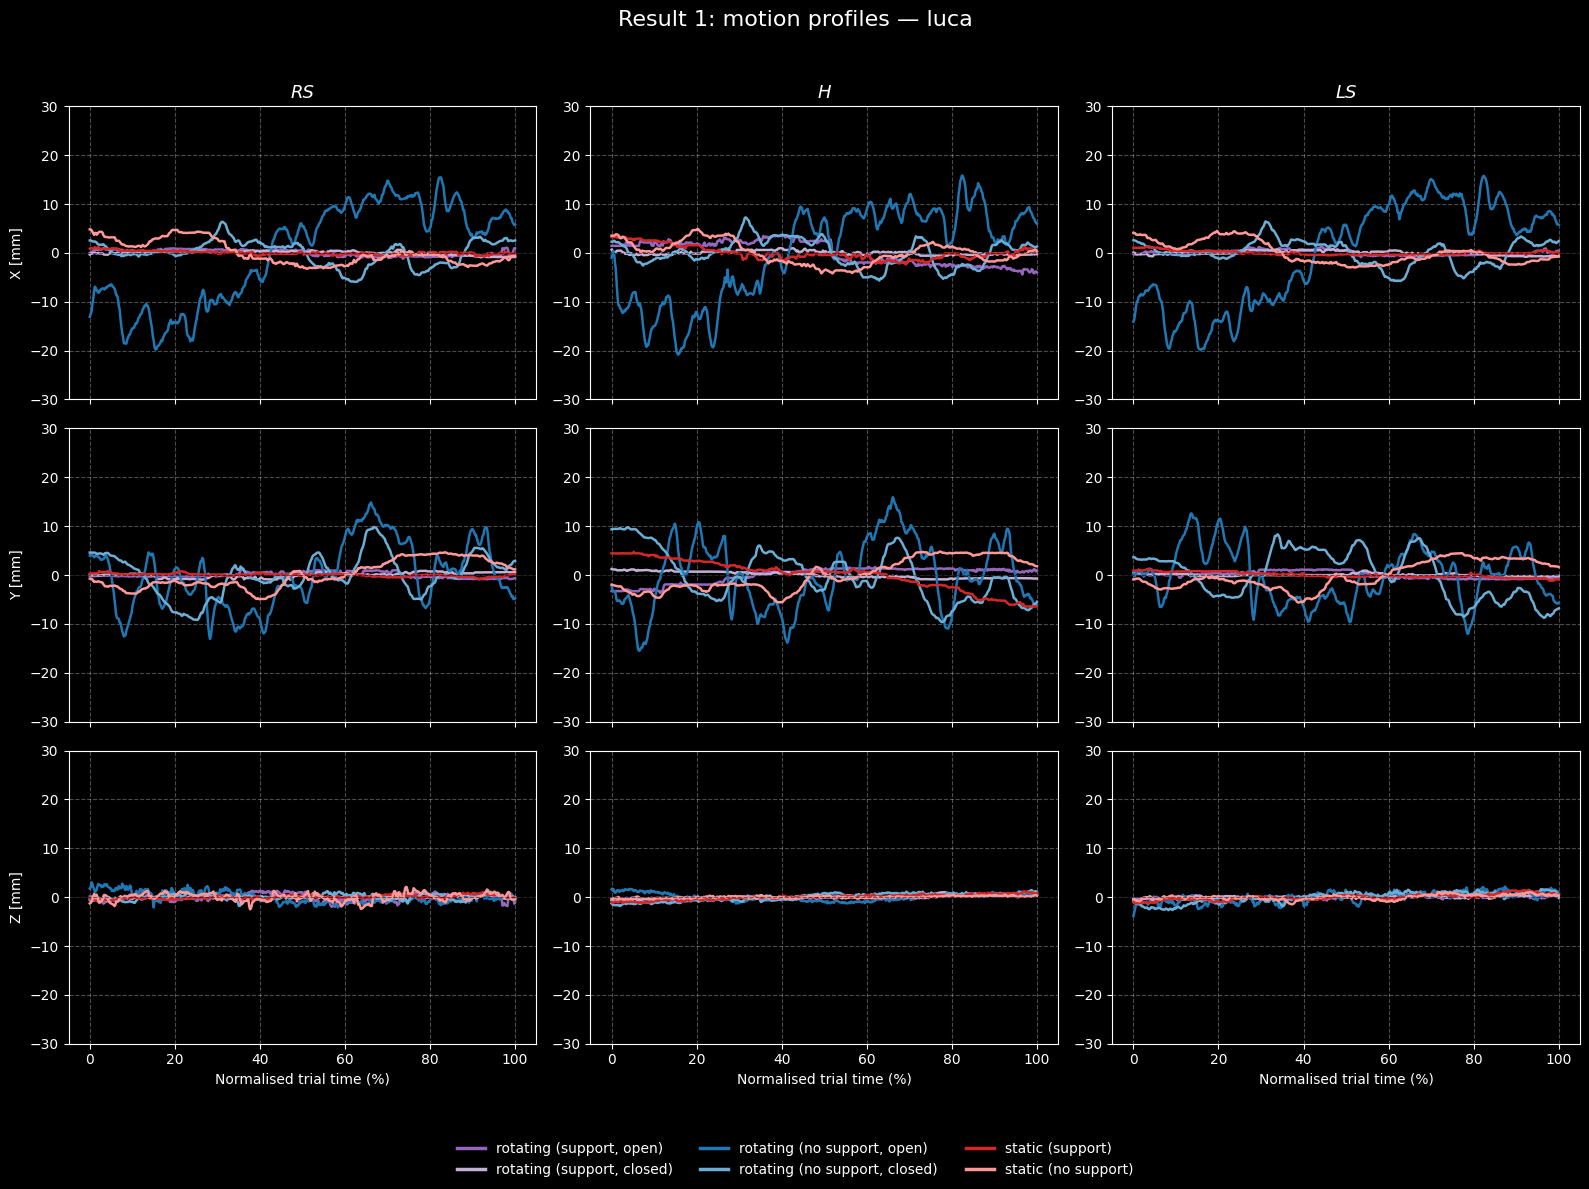

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/motion_profiles_3x3_luca.png


In [53]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------
# CONFIG
# -------------------------
base_dir = "/Volumes/Bapje_boris/Mariona/RecordingsMariona"
participants = ["jose", "jens", "mariona", "luca"]  # add "ann" / others if available
output_folder = os.path.join(base_dir, "MotionProfiles")
os.makedirs(output_folder, exist_ok=True)

trim = 30  # samples trimmed from each end
N = 500  # common length: each trial resampled onto N points so they overlay

# --- map each position to its marker column(s). EDIT to your real layout. ---
positions = {
    "RS": ["pt1", "pt2"],  # right shoulder  (PLACEHOLDER)
    "H": ["pt3", "pt4"],  # head            (PLACEHOLDER)
    "LS": ["pt5", "pt6"],  # left shoulder   (PLACEHOLDER)
}
axes_letters = ["x", "y", "z"]
axes_names = ["X", "Y", "Z"]

# trial -> (label, color)
conditions = {
    1: ("rotating (support, open)", "#9467bd"),  # purple
    2: ("rotating (support, closed)", "#c5b0d5"),  # light purple
    3: ("rotating (no support, open)", "#1f77b4"),  # blue
    4: ("rotating (no support, closed)", "#6baed6"),  # light blue
    5: ("static (support)", "#d62728"),  # red
    6: ("static (no support)", "#ff9896"),  # light red
}


# -------------------------
# LOAD ONE PARTICIPANT + TRIAL -> position centroid per axis, resampled to N
# -------------------------
def load_positions(participant, trial):
    path = os.path.join(
        base_dir, f"{participant}{trial}", "Output_processed", "transform_3d.csv"
    )
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if len(df) <= 2 * trim:
        return None
    df = df.iloc[trim:-trim].reset_index(drop=True)

    out = {}
    new = np.linspace(0, 1, N)
    for pos, prefixes in positions.items():
        out[pos] = {}
        for ax in axes_letters:
            sig = df[[f"{p}_{ax}" for p in prefixes]].mean(axis=1)  # position centroid
            sig = (sig - sig.mean()).to_numpy()  # detrend to baseline
            old = np.linspace(0, 1, len(sig))
            out[pos][ax] = np.interp(new, old, sig)  # common time grid
    return out


# -------------------------
# ONE 3x3 FIGURE PER PARTICIPANT
# rows = axes (x,y,z), cols = positions (RS,H,LS); 6 conditions overlaid per panel
# -------------------------
t = np.linspace(0, 100, N)  # normalised trial time (%)
pos_list = list(positions.keys())

for participant in participants:
    # load every condition for this participant
    series = {}
    for trial in conditions:
        loaded = load_positions(participant, trial)
        if loaded is None:
            print(f"  [skip] {participant} trial {trial}")
            continue
        series[trial] = loaded
    if not series:
        print(f"  no data for {participant}, skipping")
        continue

    fig, axarr = plt.subplots(3, 3, figsize=(16, 12), sharex=True)
    for r, (ax_letter, ax_name) in enumerate(zip(axes_letters, axes_names)):
        for c, pos in enumerate(pos_list):
            ax = axarr[r, c]
            for trial, (label, color) in conditions.items():
                if trial not in series:
                    continue
                ax.plot(t, series[trial][pos][ax_letter],
                        color=color, linewidth=1.8)
            ax.axhline(0, color="k", linestyle="--", linewidth=0.8, alpha=0.5)
            ax.grid(True, linestyle="--", alpha=0.3)

            # ----------------------------------------------------
            # SET Y-AXIS LIMITS FOR UNIFORM SCALING
            # ----------------------------------------------------
            ax.set_ylim(-30, 30)
            # Note: If your data specifically requires an inverted scale
            # (where 15 is at the bottom and -20 is at the top), use:
            # ax.set_ylim(15, -20)
            # ----------------------------------------------------

            if r == 0:
                ax.set_title(pos, fontsize=13, fontstyle="italic")
            if c == 0:
                ax.set_ylabel(f"{ax_name} [mm]")
            if r == 2:
                ax.set_xlabel("Normalised trial time (%)")

    legend_handles = [Line2D([0], [0], color=color, lw=2.5, label=label)
                      for _, (label, color) in conditions.items()]
    fig.legend(handles=legend_handles, loc="lower center", ncol=3,
               fontsize="medium", frameon=False)
    fig.suptitle(f"Result 1: motion profiles \u2014 {participant}",
                 fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0.07, 1, 0.96])

    save_path = os.path.join(output_folder, f"motion_profiles_3x3_{participant}.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", save_path)


jose


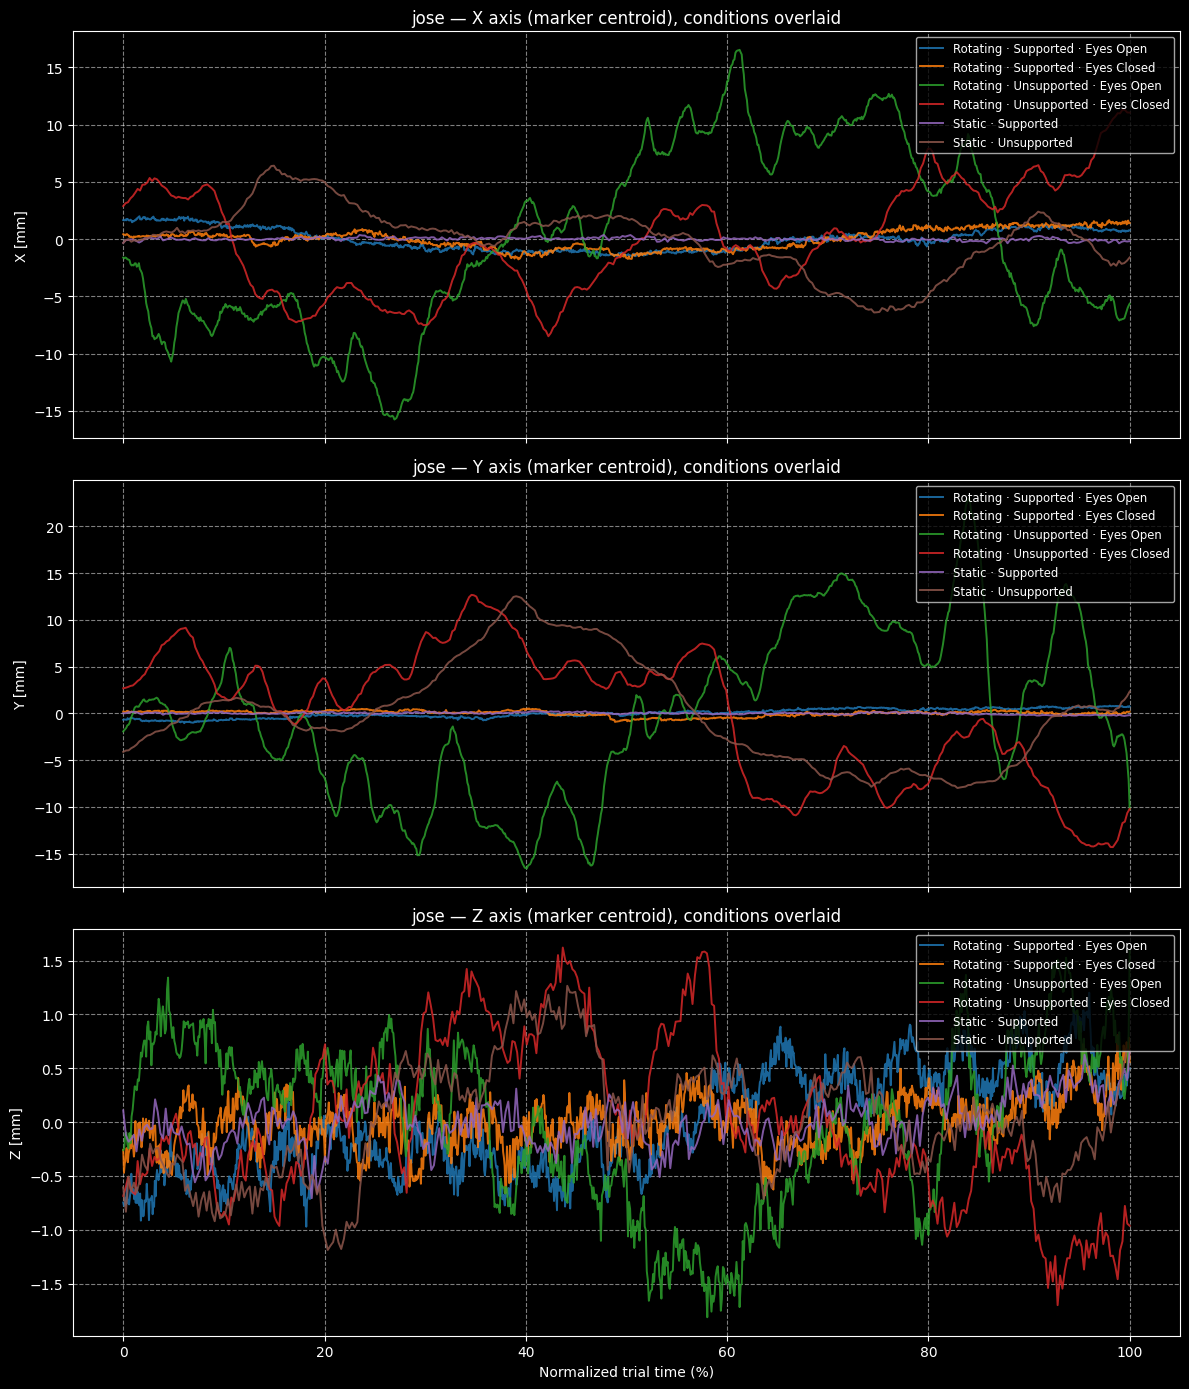

  saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/ConditionComparisons/jose_conditions_overlay.png

jens


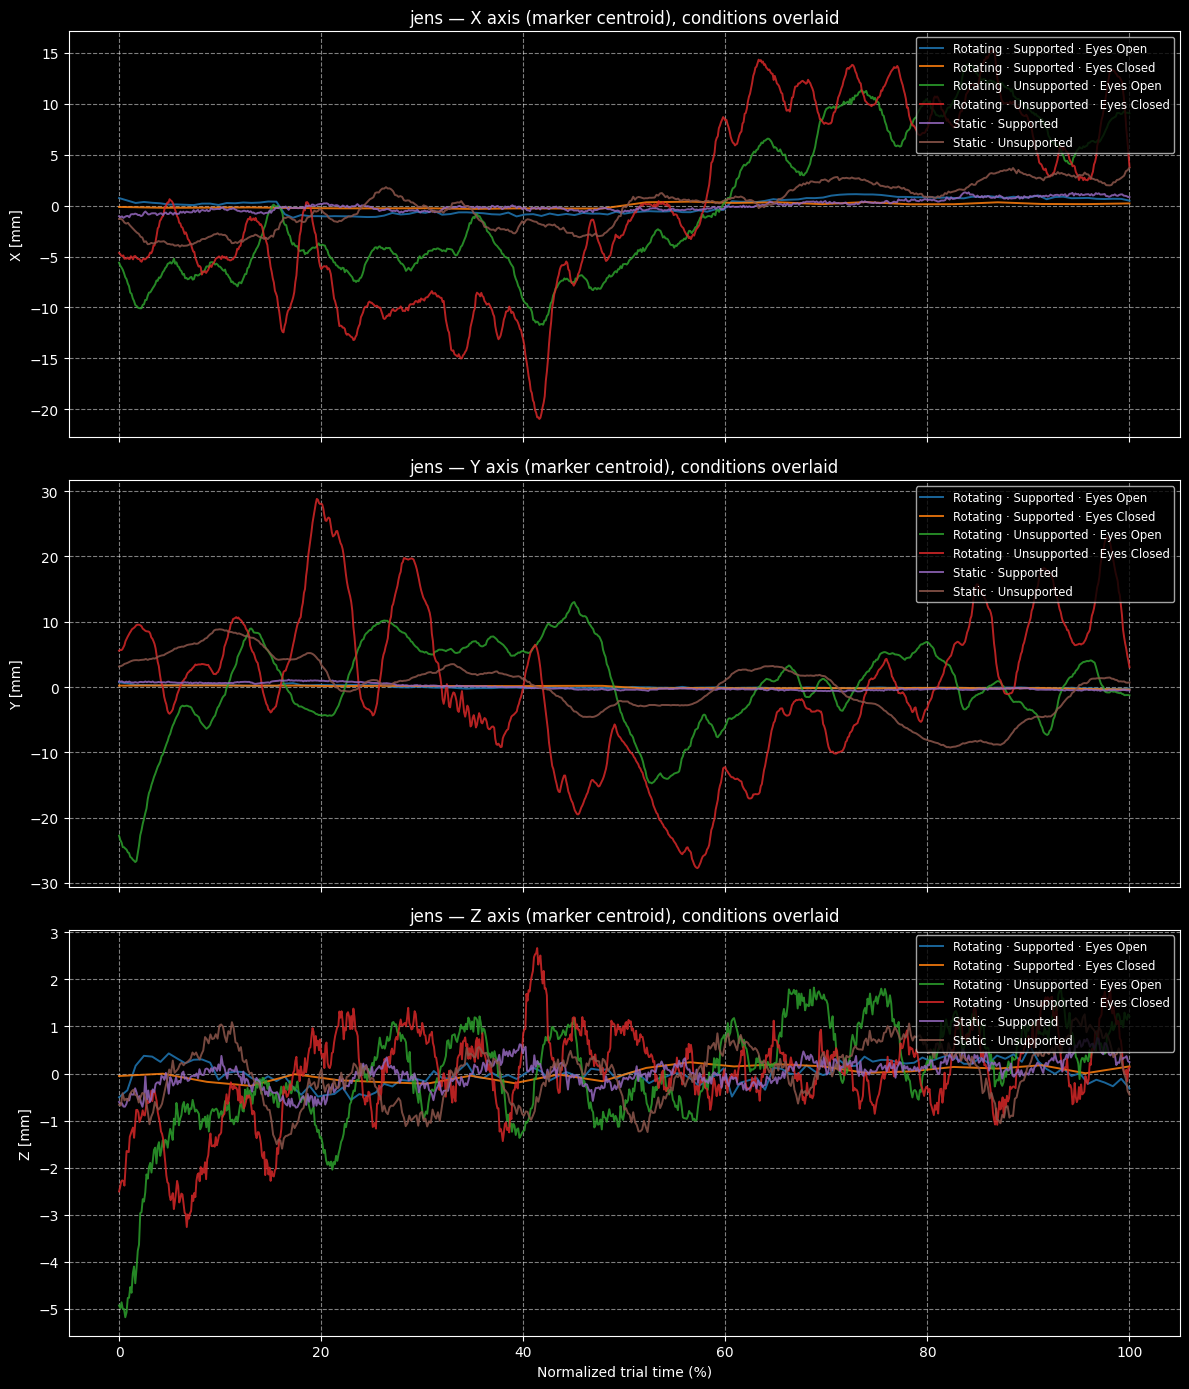

  saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/ConditionComparisons/jens_conditions_overlay.png

mariona


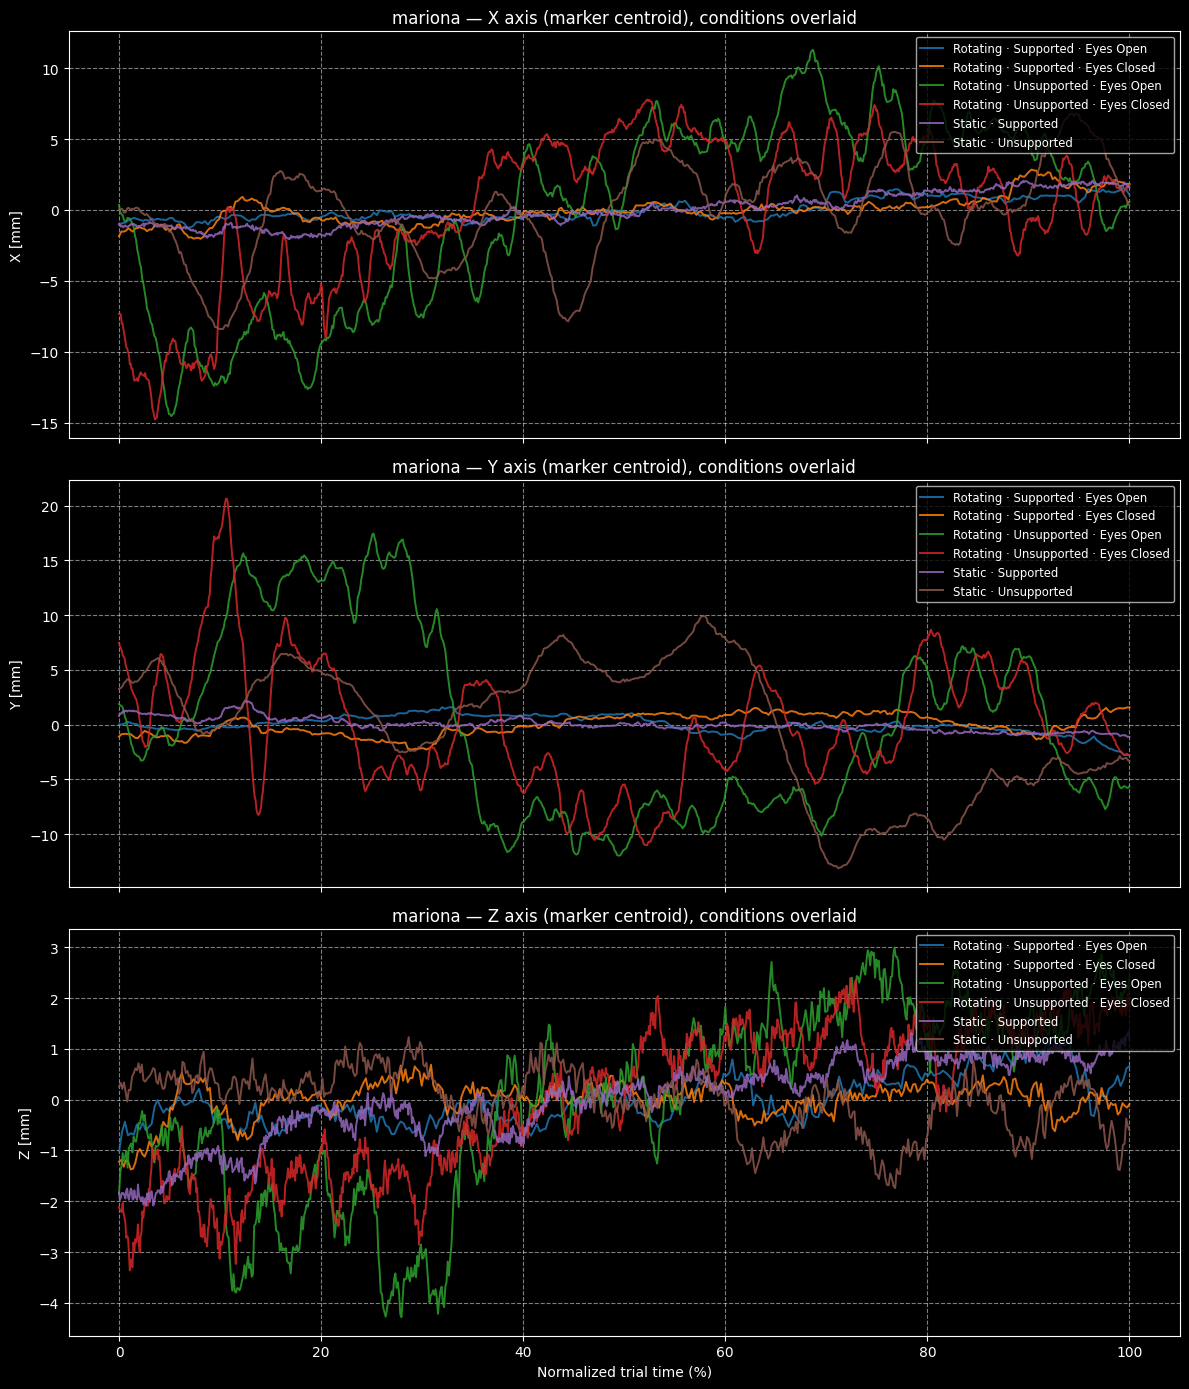

  saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/ConditionComparisons/mariona_conditions_overlay.png

luca


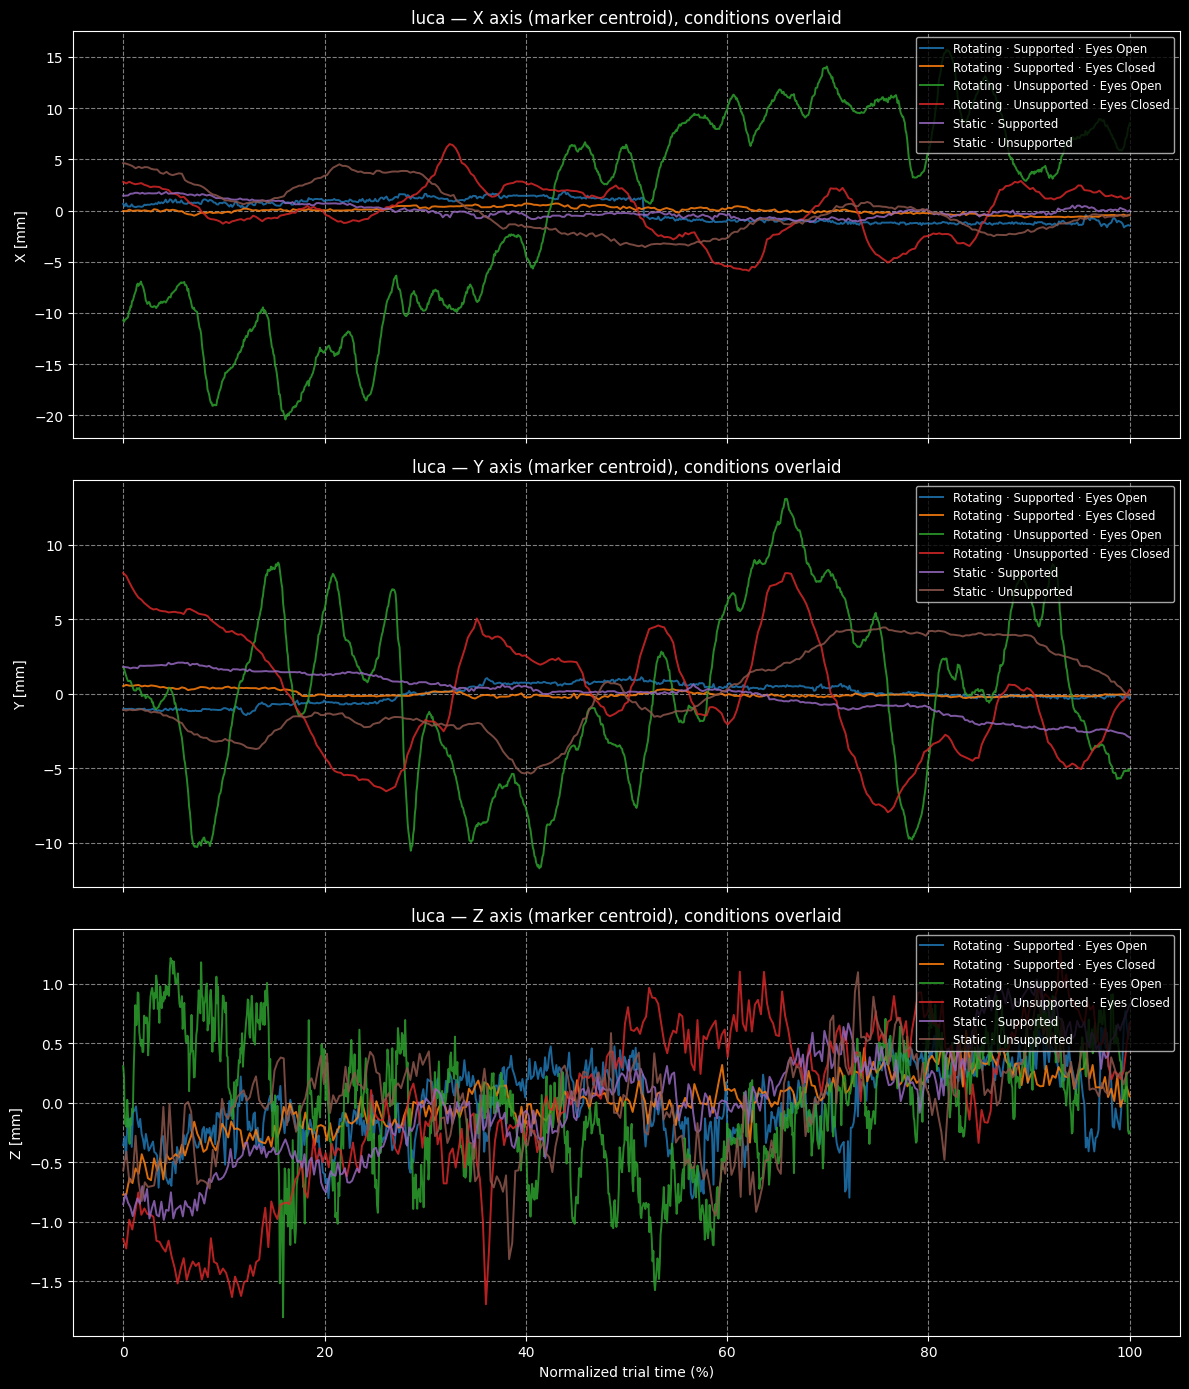

  saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/ConditionComparisons/luca_conditions_overlay.png


In [54]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------
# CONFIG
# -------------------------
base_dir = "/Volumes/Bapje_boris/Mariona/RecordingsMariona"
participants = [ "jose", "jens", "mariona", "luca"]
output_folder = os.path.join(base_dir, "ConditionComparisons")
os.makedirs(output_folder, exist_ok=True)

trim = 20  # samples trimmed from each end (as in your original script)
collapse = "centroid"  # "centroid" -> mean of the 6 markers ; "single" -> one marker
single_marker = "pt1"  # used only when collapse == "single"
fps = None  # set e.g. 30 for real seconds; None -> normalized 0-100% time

marker_prefixes = ["pt1", "pt2", "pt3", "pt4", "pt5", "pt6"]
axes_letters = ["x", "y", "z"]
axes_names = ["X", "Y", "Z"]

# Trial -> condition label (from your table).
# Trials 1-4 = rotating/dynamic platform, 5-6 = static. Edit freely.
conditions = {
    1: "Rotating · Supported · Eyes Open",
    2: "Rotating · Supported · Eyes Closed",
    3: "Rotating · Unsupported · Eyes Open",
    4: "Rotating · Unsupported · Eyes Closed",
    5: "Static · Supported",
    6: "Static · Unsupported",
}
cond_colors = {
    1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c",
    4: "#d62728", 5: "#9467bd", 6: "#8c564b",
}


# -------------------------
# LOAD + COLLAPSE ONE TRIAL TO A SINGLE SIGNAL PER AXIS
# -------------------------
def load_trial(participant, trial):
    path = os.path.join(
        base_dir, f"{participant}{trial}", "Output_processed", "transform_3d.csv"
    )
    if not os.path.exists(path):
        print(f"  [skip] missing: {path}")
        return None

    df = pd.read_csv(path)
    if len(df) <= 2 * trim:
        print(f"  [skip] too short after trim: {path}")
        return None
    df = df.iloc[trim:-trim].reset_index(drop=True)

    out = {}
    for ax in axes_letters:
        if collapse == "centroid":
            # mean across the 6 markers -> cancels most bulk rotation, keeps net sway
            sig = df[[f"{p}_{ax}" for p in marker_prefixes]].mean(axis=1)
        else:
            sig = df[f"{single_marker}_{ax}"]
        out[ax] = (sig - sig.mean()).to_numpy()  # detrend to its own baseline
    return out


# -------------------------
# ONE FIGURE PER PARTICIPANT: 3 axes, conditions overlaid
# -------------------------
def make_condition_figure(participant):
    print(f"\n{participant}")
    series = {}
    for trial in conditions:
        data = load_trial(participant, trial)
        if data is not None:
            series[trial] = data
    if not series:
        print("  no trials found, skipping figure")
        return

    fig, axarr = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
    xlabel = "Time (s)" if fps else "Normalized trial time (%)"

    for i, (ax_letter, ax_name) in enumerate(zip(axes_letters, axes_names)):
        ax = axarr[i]
        for trial, data in series.items():
            y = data[ax_letter]
            x = np.arange(len(y)) / fps if fps else np.linspace(0, 100, len(y))
            ax.plot(
                x, y,
                label=conditions[trial],
                color=cond_colors[trial],
                linewidth=1.4, alpha=0.85,
            )
        src = "marker centroid" if collapse == "centroid" else single_marker
        ax.set_ylabel(f"{ax_name} [mm]")
        ax.set_title(f"{participant} — {ax_name} axis ({src}), conditions overlaid")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="upper right", fontsize="small")

    axarr[-1].set_xlabel(xlabel)
    plt.tight_layout()
    save_path = os.path.join(output_folder, f"{participant}_conditions_overlay.png")
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("  saved:", save_path)


# -------------------------
# RUN FOR EVERY PARTICIPANT
# -------------------------
for p in participants:
    make_condition_figure(p)

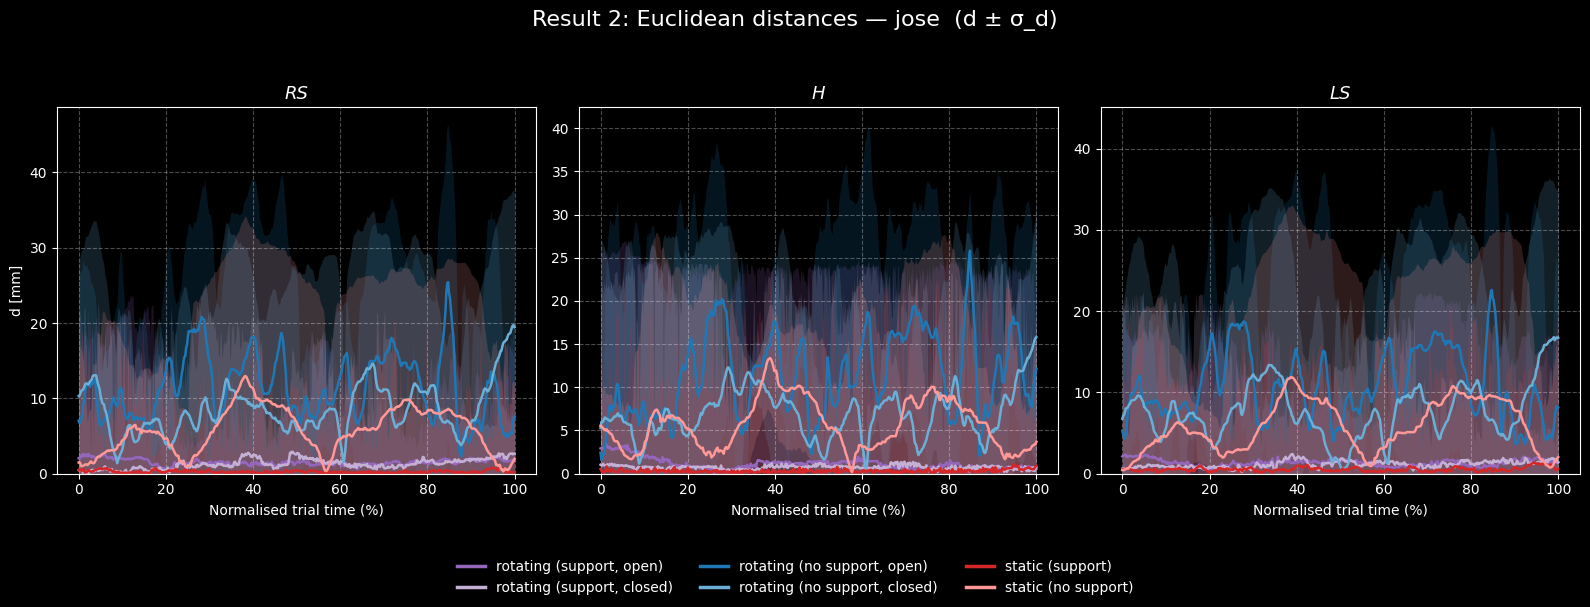

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/euclidean_distances_jose.png


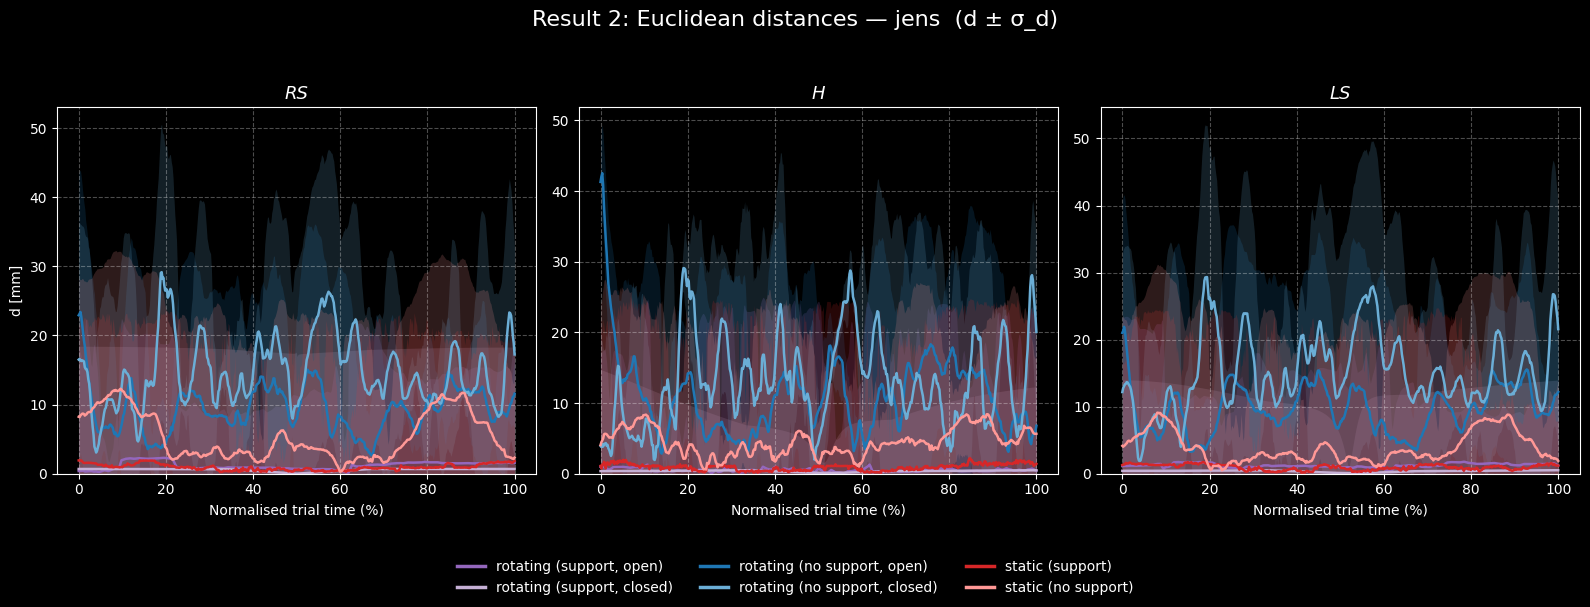

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/euclidean_distances_jens.png


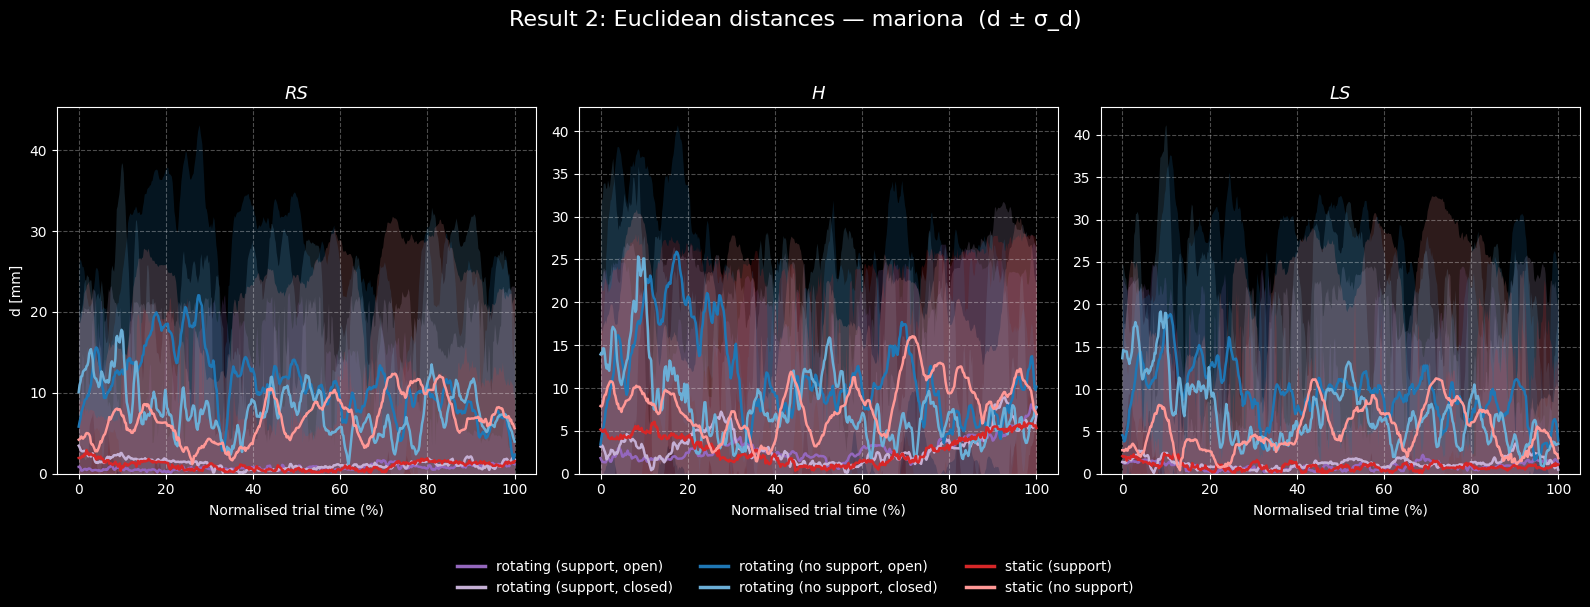

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/euclidean_distances_mariona.png


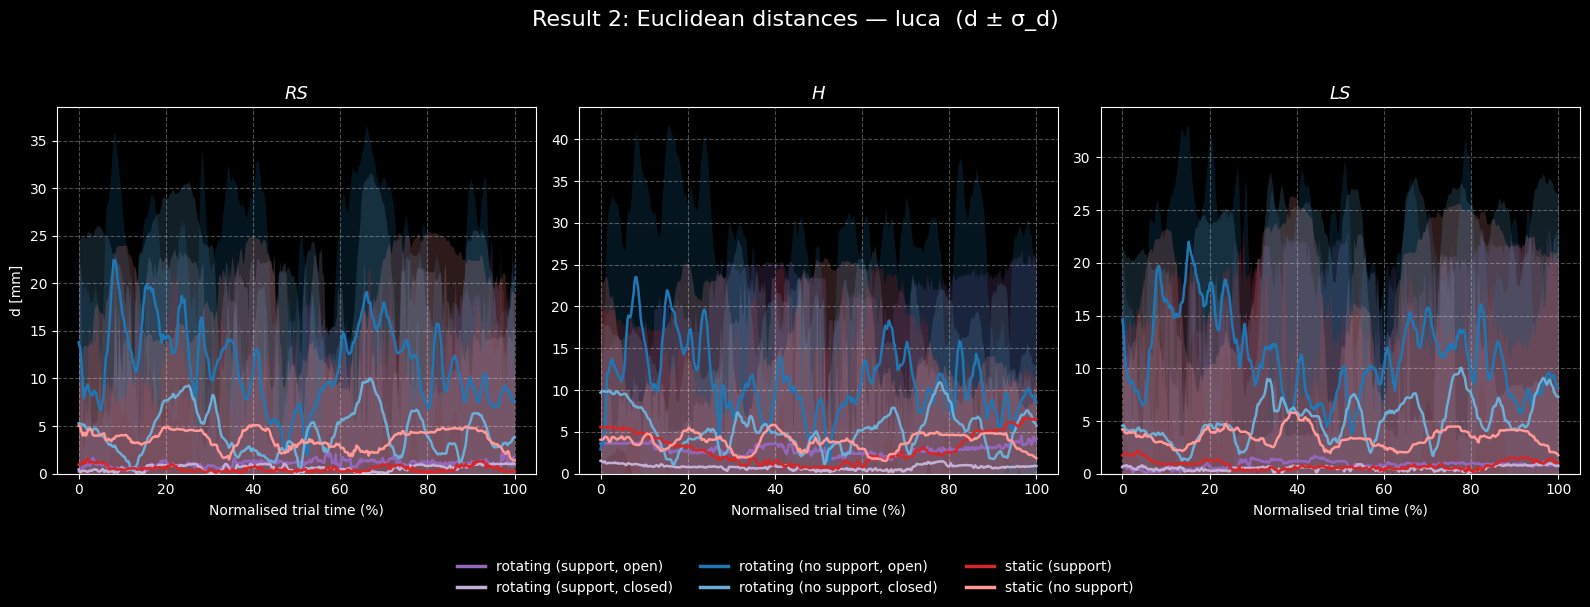

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/euclidean_distances_luca.png


In [60]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------------
# CONFIG
# -------------------------
base_dir = "/Volumes/Bapje_boris/Mariona/RecordingsMariona"
participants = ["jose", "jens", "mariona", "luca"]  # add "ann" / others if available
output_folder = os.path.join(base_dir, "MotionProfiles")
os.makedirs(output_folder, exist_ok=True)

trim = 30  # samples trimmed from each end
N = 500  # common length: each trial resampled onto N points
show_band = True  # sigma_d band; here sigma_x/y/z = std ACROSS the position's markers

# --- map each position to its marker column(s). EDIT to your real layout. ---
# Each position needs >= 2 markers for the band to be non-zero.
positions = {
    "RS": ["pt1", "pt2"],  # right shoulder  (PLACEHOLDER)
    "H": ["pt3", "pt4"],  # head            (PLACEHOLDER)
    "LS": ["pt5", "pt6"],  # left shoulder   (PLACEHOLDER)
}
axes_letters = ["x", "y", "z"]

# trial -> (label, color)
conditions = {
    1: ("rotating (support, open)", "#9467bd"),  # purple
    2: ("rotating (support, closed)", "#c5b0d5"),  # light purple
    3: ("rotating (no support, open)", "#1f77b4"),  # blue
    4: ("rotating (no support, closed)", "#6baed6"),  # light blue
    5: ("static (support)", "#d62728"),  # red
    6: ("static (no support)", "#ff9896"),  # light red
}


# -------------------------
# LOAD ONE PARTICIPANT + TRIAL
# returns out[pos][ax] = (centroid_detrended, std_across_markers), each length N
# -------------------------
def load_positions(participant, trial):
    path = os.path.join(
        base_dir, f"{participant}{trial}", "Output_processed", "transform_3d.csv"
    )
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if len(df) <= 2 * trim:
        return None
    df = df.iloc[trim:-trim].reset_index(drop=True)

    out = {}
    new = np.linspace(0, 1, N)
    for pos, prefixes in positions.items():
        out[pos] = {}
        for ax in axes_letters:
            M = df[[f"{p}_{ax}" for p in prefixes]].to_numpy()  # (T, n_markers)
            centroid = M.mean(axis=1)
            centroid = centroid - centroid.mean()  # detrend to baseline
            spread = M.std(axis=1)  # std across markers
            old = np.linspace(0, 1, len(centroid))
            out[pos][ax] = (np.interp(new, old, centroid),
                            np.interp(new, old, spread))
    return out


# -------------------------
# EUCLIDEAN DISTANCE d(t) AND PROPAGATED sigma_d(t) for one trial/position
# d       = sqrt(cx^2 + cy^2 + cz^2)
# sigma_d = sqrt(cx^2 sx^2 + cy^2 sy^2 + cz^2 sz^2) / d
# -------------------------
def distance_and_sigma(loaded, pos):
    (cx, sx) = loaded[pos]["x"]
    (cy, sy) = loaded[pos]["y"]
    (cz, sz) = loaded[pos]["z"]
    d = np.sqrt(cx ** 2 + cy ** 2 + cz ** 2)
    eps = 1e-9
    sigma_d = np.sqrt((cx ** 2) * (sx ** 2) + (cy ** 2) * (sy ** 2) + (cz ** 2) * (sz ** 2)) / (d + eps)
    return d, sigma_d


# -------------------------
# ONE FIGURE PER PARTICIPANT: 1 row x 3 cols (RS, H, LS), d(t), 6 conditions overlaid
# -------------------------
t = np.linspace(0, 100, N)  # normalised trial time (%)
pos_list = list(positions.keys())

for participant in participants:
    series = {}
    for trial in conditions:
        loaded = load_positions(participant, trial)
        if loaded is None:
            print(f"  [skip] {participant} trial {trial}")
            continue
        series[trial] = loaded
    if not series:
        print(f"  no data for {participant}, skipping")
        continue

    fig, axarr = plt.subplots(1, 3, figsize=(16, 6), sharex=True)
    if len(pos_list) == 1:
        axarr = [axarr]

    for c, pos in enumerate(pos_list):
        ax = axarr[c]
        for trial, (label, color) in conditions.items():
            if trial not in series:
                continue
            d, sigma_d = distance_and_sigma(series[trial], pos)
            ax.plot(t, d, color=color, linewidth=1.8)
            if show_band:
                ax.fill_between(t, np.clip(d - sigma_d, 0, None), d + sigma_d,
                                color=color, alpha=0.18, linewidth=0)
        ax.set_ylim(bottom=0)
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.set_title(pos, fontsize=13, fontstyle="italic")
        ax.set_xlabel("Normalised trial time (%)")
        if c == 0:
            ax.set_ylabel("d [mm]")

    legend_handles = [Line2D([0], [0], color=color, lw=2.5, label=label)
                      for _, (label, color) in conditions.items()]
    fig.legend(handles=legend_handles, loc="lower center", ncol=3,
               fontsize="medium", frameon=False)
    fig.suptitle(f"Result 2: Euclidean distances \u2014 {participant}  (d \u00b1 \u03c3_d)",
                 fontsize=16, y=0.99)
    plt.tight_layout(rect=[0, 0.12, 1, 0.95])

    save_path = os.path.join(output_folder, f"euclidean_distances_{participant}.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", save_path)

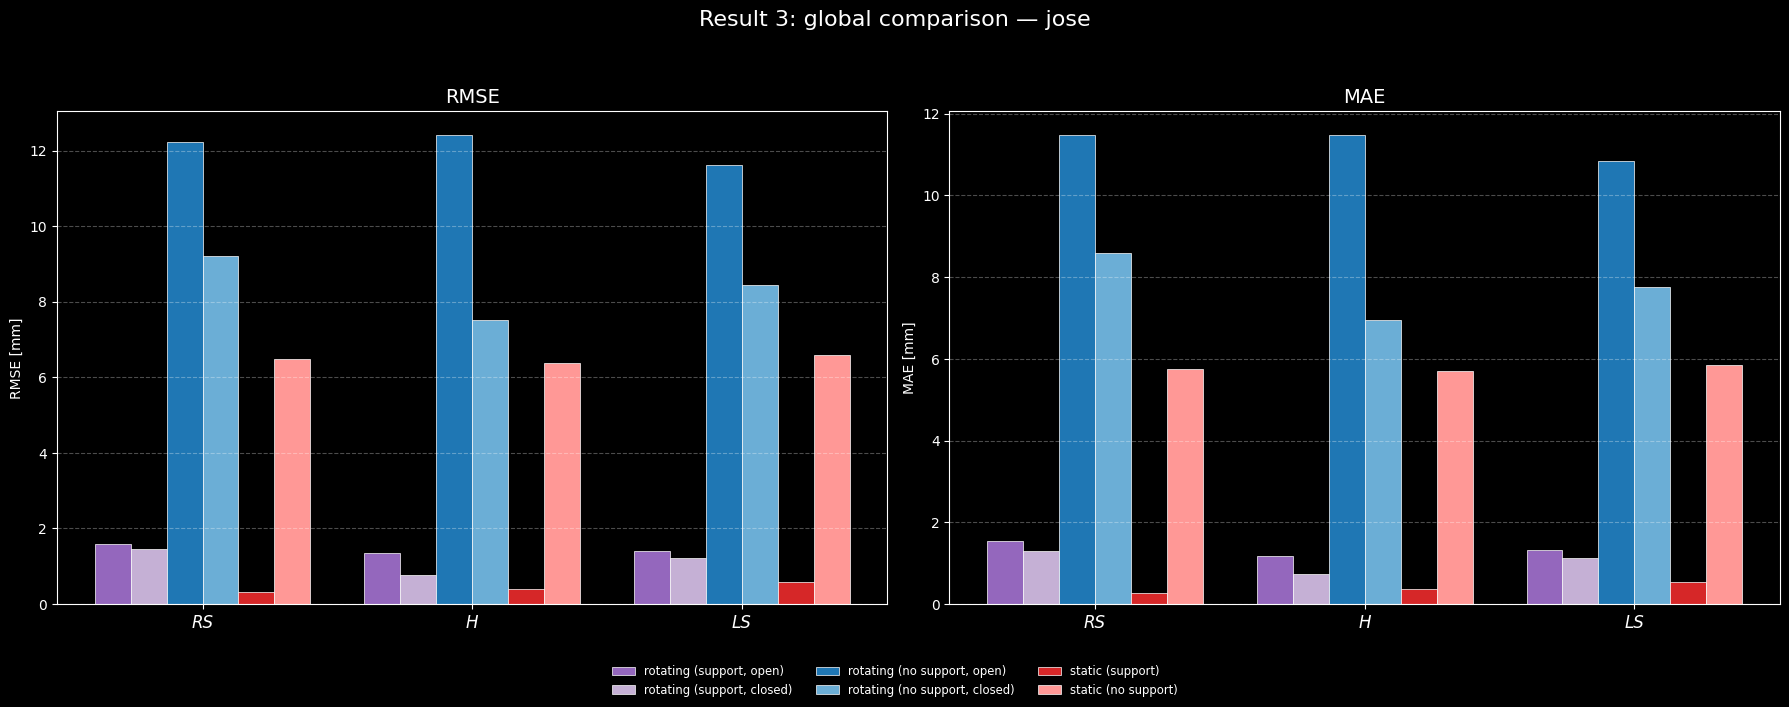

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/global_comparison_jose.png


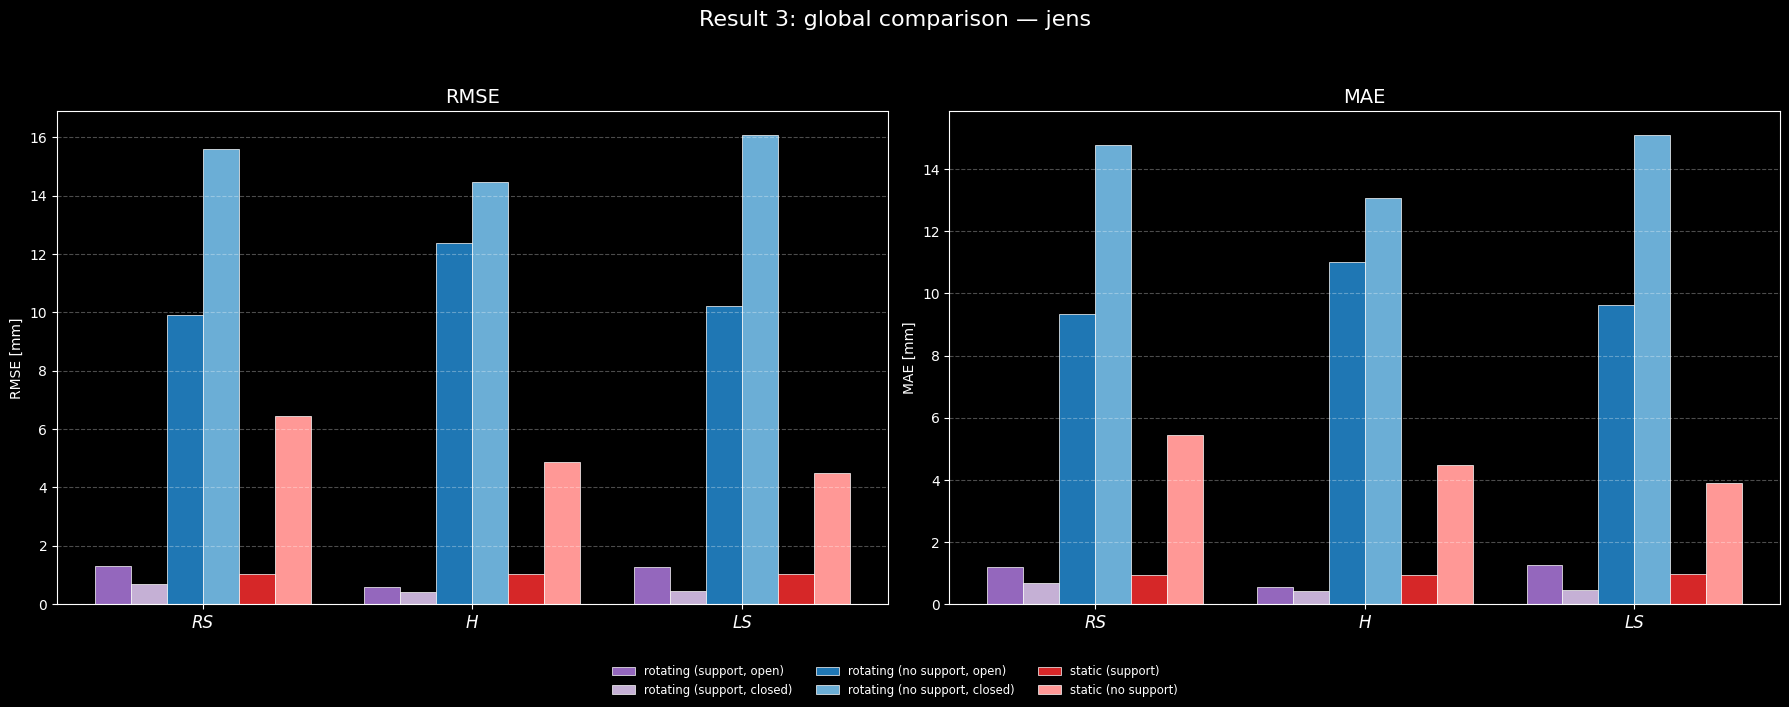

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/global_comparison_jens.png


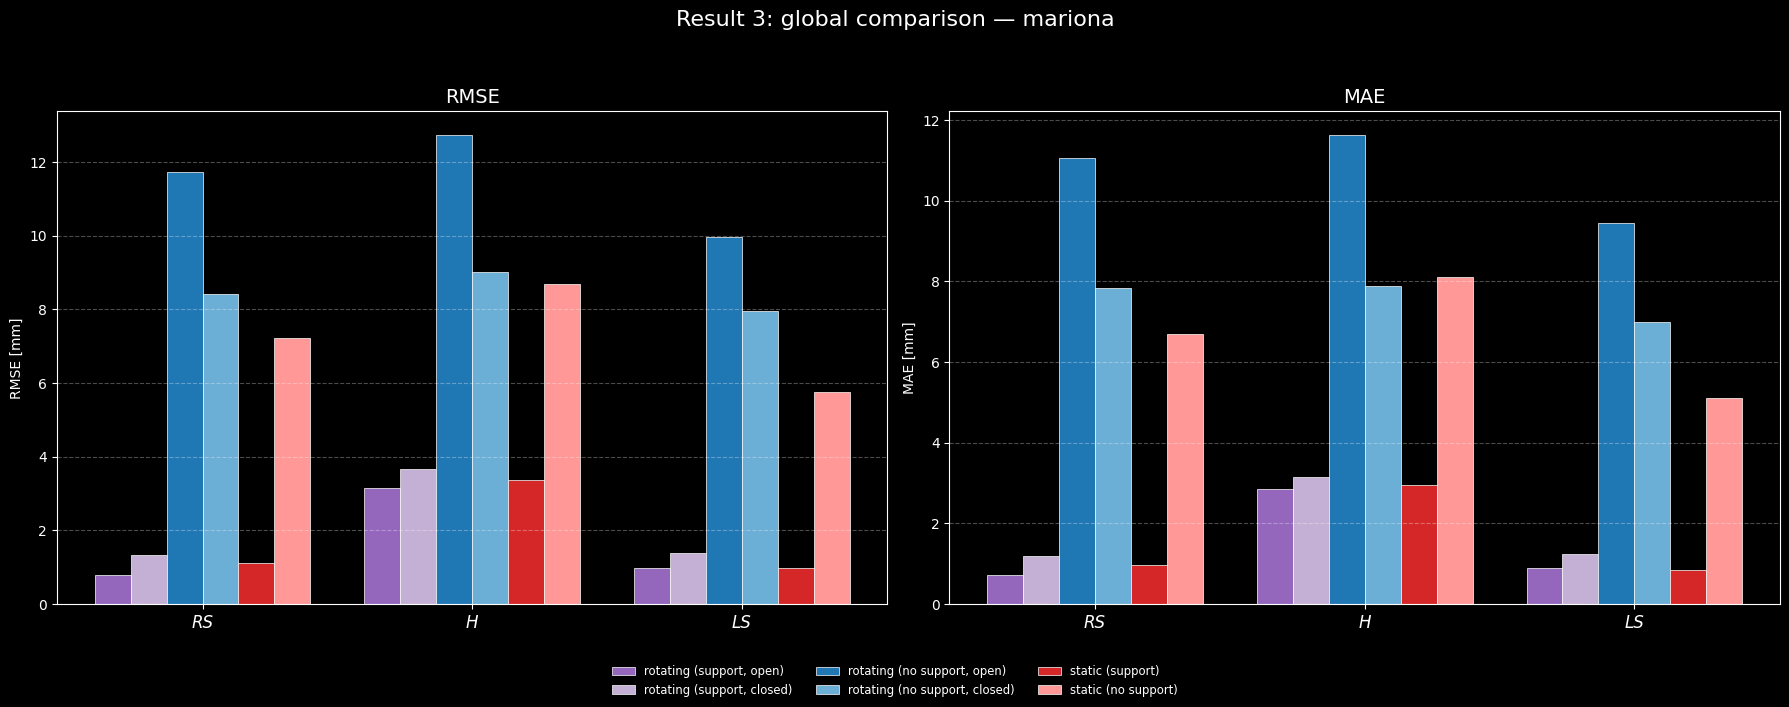

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/global_comparison_mariona.png


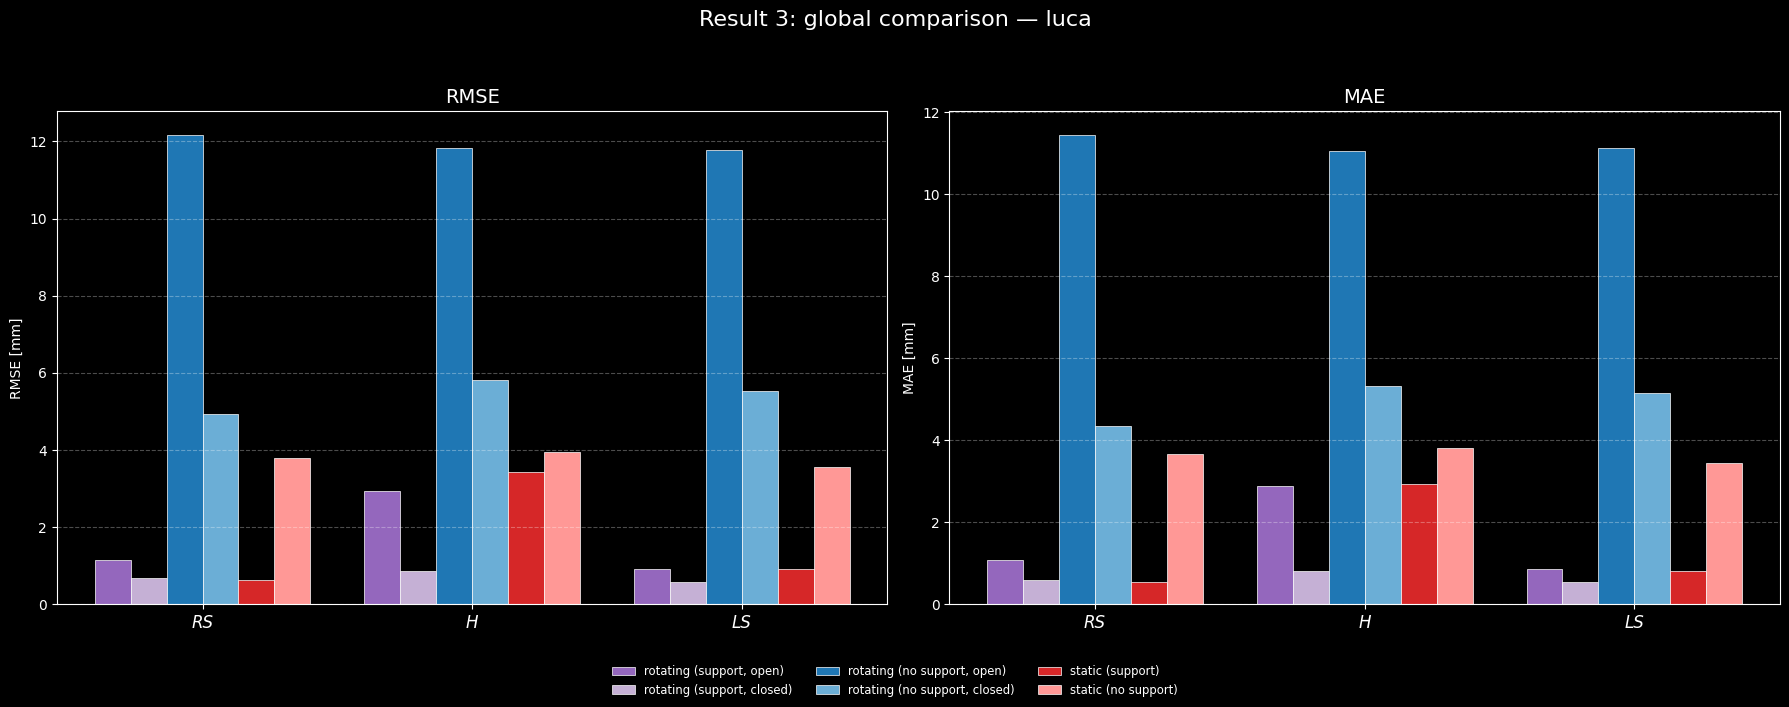

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/global_comparison_luca.png


In [62]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
base_dir = "/Volumes/Bapje_boris/Mariona/RecordingsMariona"
participants = ["jose", "jens", "mariona", "luca"]  # add "ann" / others if available
output_folder = os.path.join(base_dir, "MotionProfiles")
os.makedirs(output_folder, exist_ok=True)

trim = 30  # samples trimmed from each end

# --- map each position to its marker column(s). EDIT to your real layout. ---
positions = {
    "RS": ["pt1", "pt2"],  # right shoulder  (PLACEHOLDER)
    "H": ["pt3", "pt4"],  # head            (PLACEHOLDER)
    "LS": ["pt5", "pt6"],  # left shoulder   (PLACEHOLDER)
}
axes_letters = ["x", "y", "z"]

# trial -> (label, color)
conditions = {
    1: ("rotating (support, open)", "#9467bd"),  # purple
    2: ("rotating (support, closed)", "#c5b0d5"),  # light purple
    3: ("rotating (no support, open)", "#1f77b4"),  # blue
    4: ("rotating (no support, closed)", "#6baed6"),  # light blue
    5: ("static (support)", "#d62728"),  # red
    6: ("static (no support)", "#ff9896"),  # light red
}


# -------------------------
# PER VOLUNTEER + TRIAL + POSITION -> scalar RMSE and MAE of d(t)
# d(t) = sqrt(cx^2 + cy^2 + cz^2), cx/cy/cz = detrended position centroid
# RMSE = sqrt(mean(d^2)) ; MAE = mean(d)   (d >= 0)
# -------------------------
def metrics_for(participant, trial):
    path = os.path.join(
        base_dir, f"{participant}{trial}", "Output_processed", "transform_3d.csv"
    )
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if len(df) <= 2 * trim:
        return None
    df = df.iloc[trim:-trim].reset_index(drop=True)

    out = {}
    for pos, prefixes in positions.items():
        coords = {}
        for ax in axes_letters:
            sig = df[[f"{p}_{ax}" for p in prefixes]].mean(axis=1)  # centroid
            coords[ax] = (sig - sig.mean()).to_numpy()  # detrend
        d = np.sqrt(coords["x"] ** 2 + coords["y"] ** 2 + coords["z"] ** 2)
        out[pos] = {
            "RMSE": float(np.sqrt(np.mean(d ** 2))),
            "MAE": float(np.mean(d)),
        }
    return out


# -------------------------
# ONE FIGURE PER PARTICIPANT: RMSE and MAE as two grouped bar charts
# x = positions (RS, H, LS); bars grouped by condition; single value per bar
# -------------------------
metric_names = ["RMSE", "MAE"]
pos_list = list(positions.keys())
trials = list(conditions.keys())
x = np.arange(len(pos_list))
n_cond = len(trials)
width = 0.8 / n_cond

for participant in participants:
    # gather this participant's scalars: data[metric][trial][pos]
    data = {m: {tr: {pos: np.nan for pos in positions} for tr in conditions}
            for m in metric_names}
    found = False
    for trial in conditions:
        res = metrics_for(participant, trial)
        if res is None:
            print(f"  [skip] {participant} trial {trial}")
            continue
        found = True
        for pos in positions:
            for m in metric_names:
                data[m][trial][pos] = res[pos][m]
    if not found:
        print(f"  no data for {participant}, skipping")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for mi, metric in enumerate(metric_names):
        ax = axes[mi]
        for k, trial in enumerate(trials):
            label, color = conditions[trial]
            heights = [data[metric][trial][pos] for pos in pos_list]
            offset = (k - (n_cond - 1) / 2) * width
            ax.bar(x + offset, heights, width,
                   color=color, label=label, edgecolor="white", linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(pos_list, fontstyle="italic", fontsize=12)
        ax.set_ylabel(f"{metric} [mm]")
        ax.set_title(metric, fontsize=14)
        ax.grid(True, axis="y", linestyle="--", alpha=0.3)

    # single shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3,
               fontsize="small", frameon=False)
    fig.suptitle(f"Result 3: global comparison \u2014 {participant}", fontsize=16, y=0.99)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])

    save_path = os.path.join(output_folder, f"global_comparison_{participant}.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", save_path)

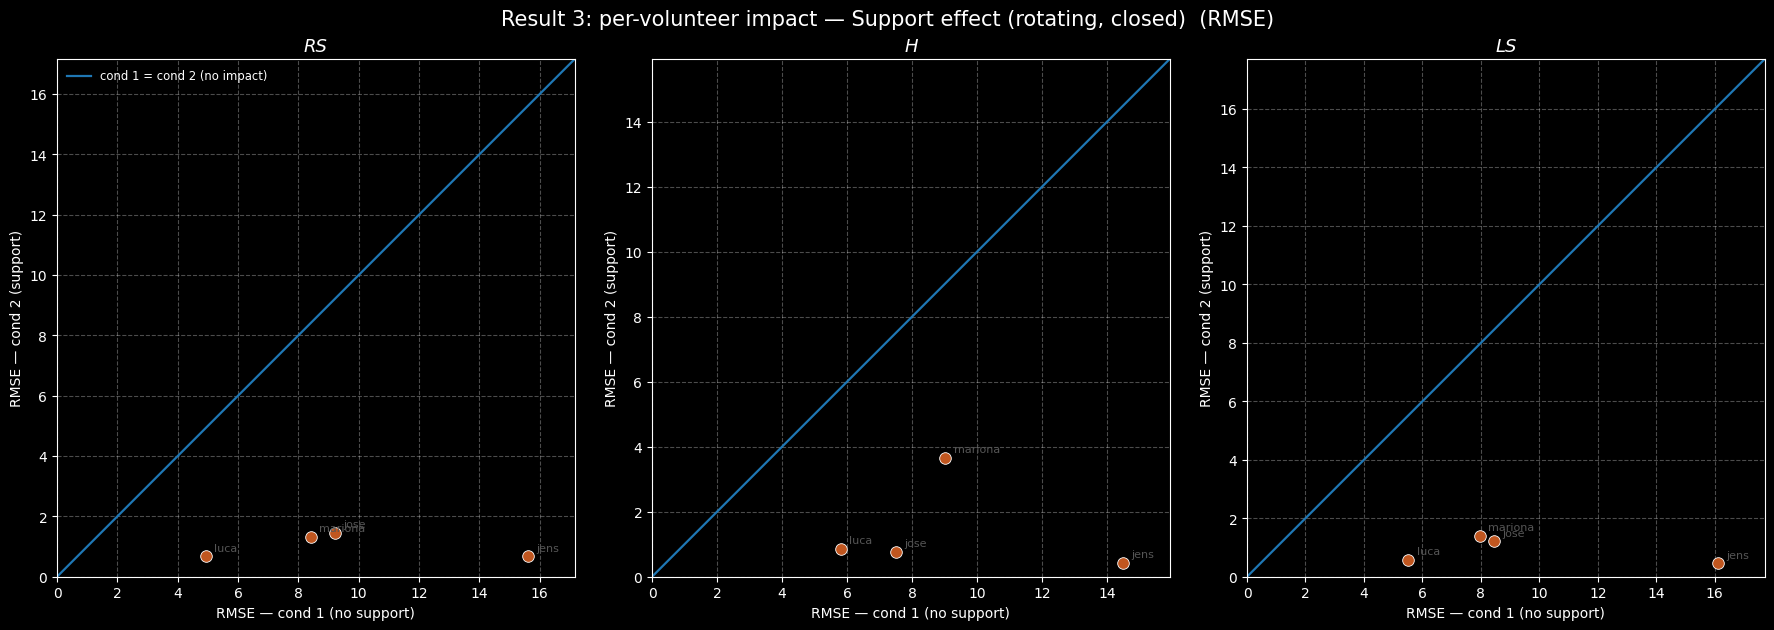

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/impact_Support_effect_rotating_closed_RMSE.png


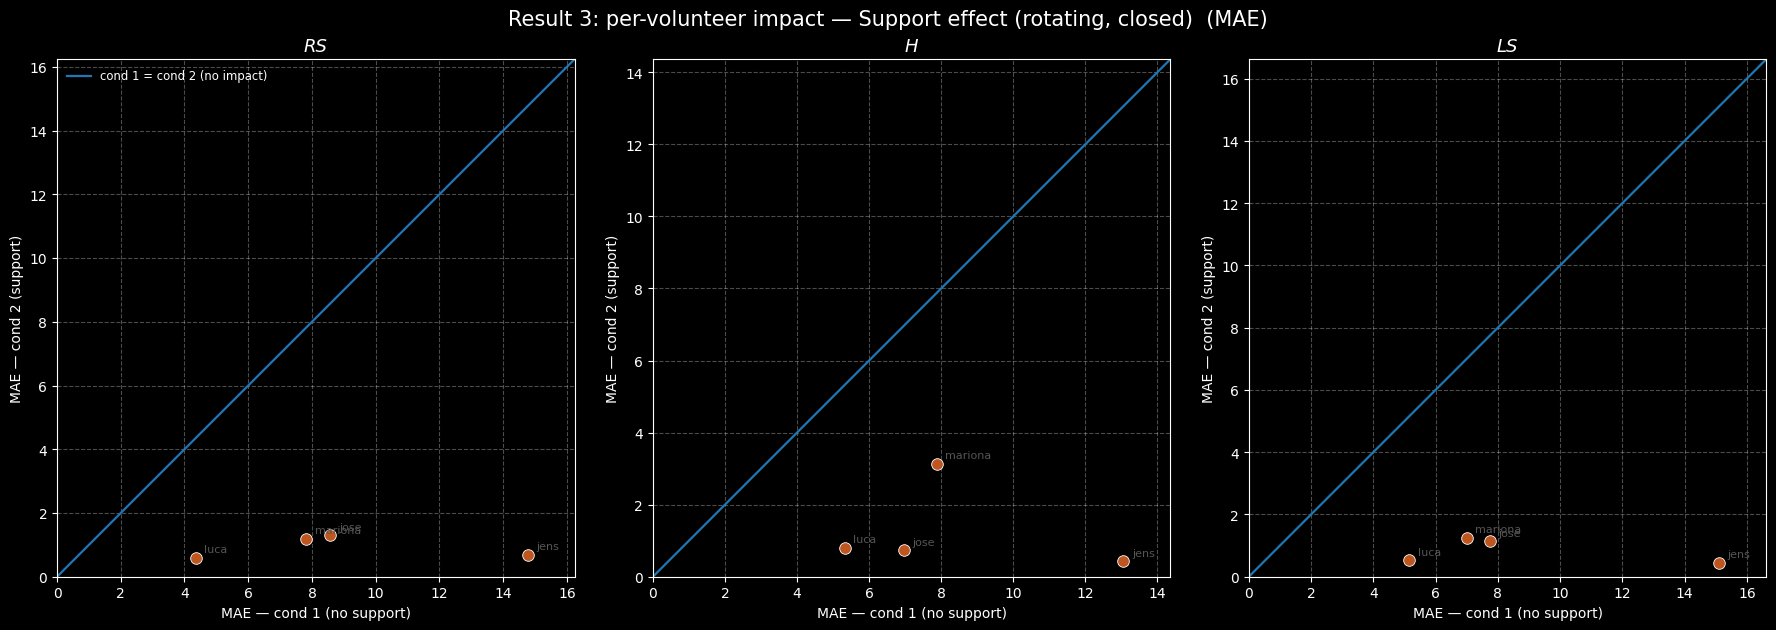

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/impact_Support_effect_rotating_closed_MAE.png


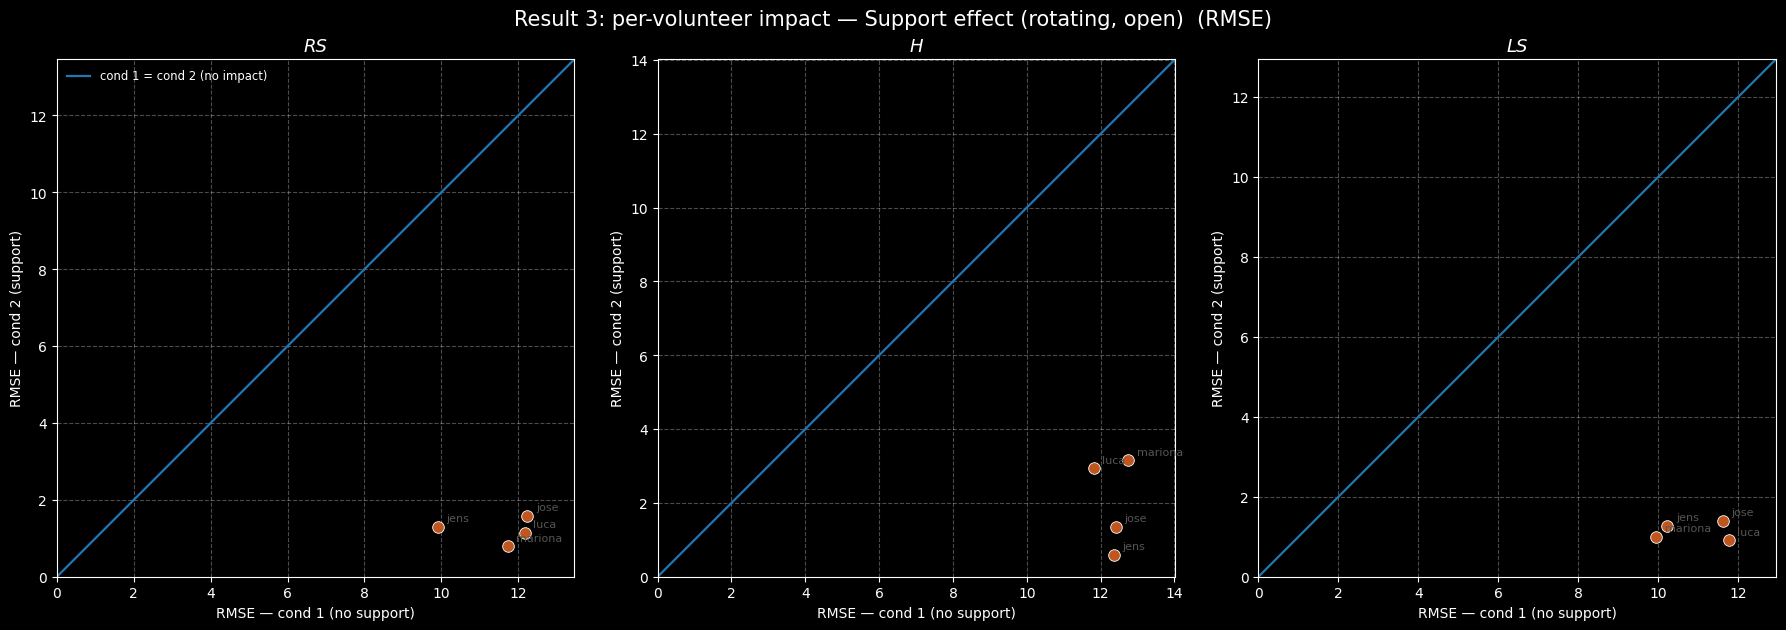

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/impact_Support_effect_rotating_open_RMSE.png


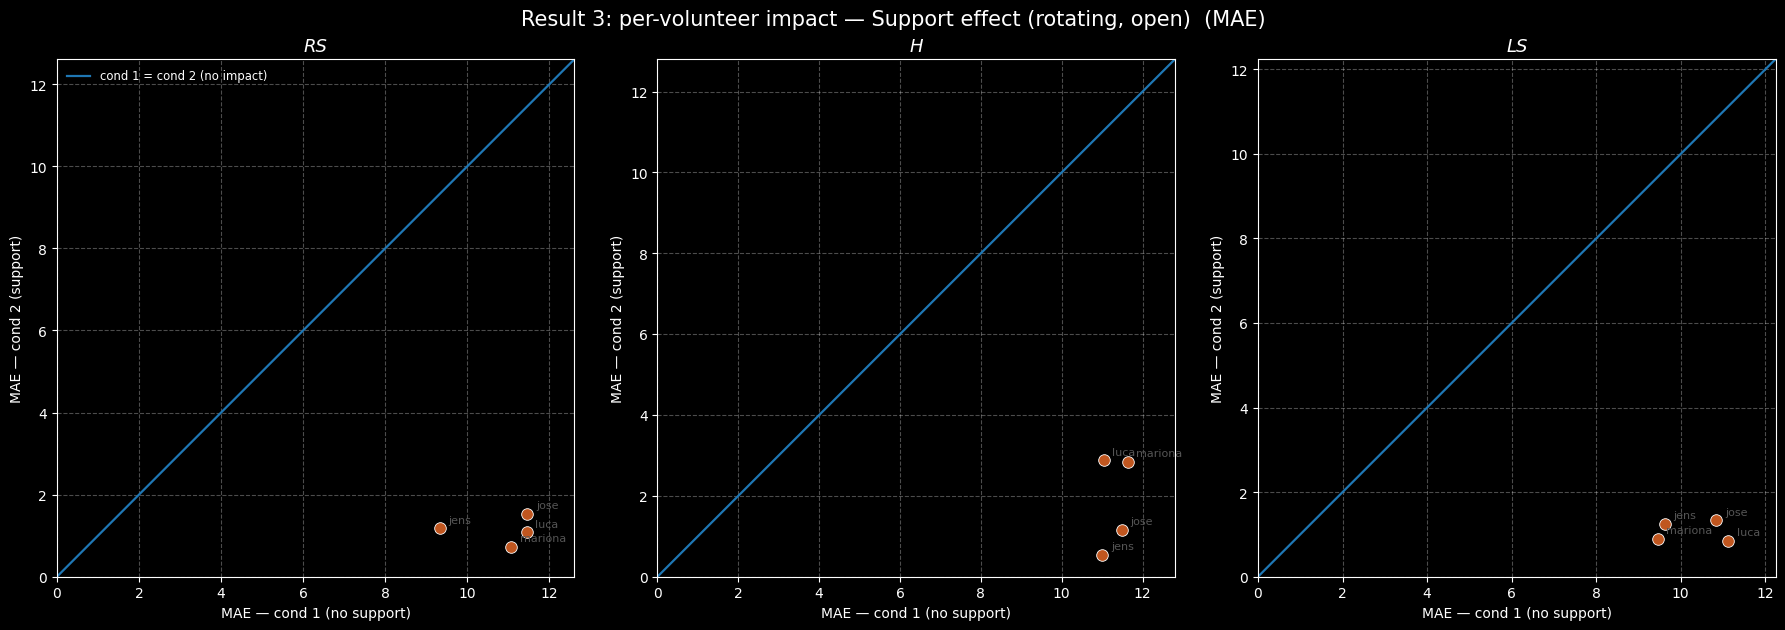

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/impact_Support_effect_rotating_open_MAE.png


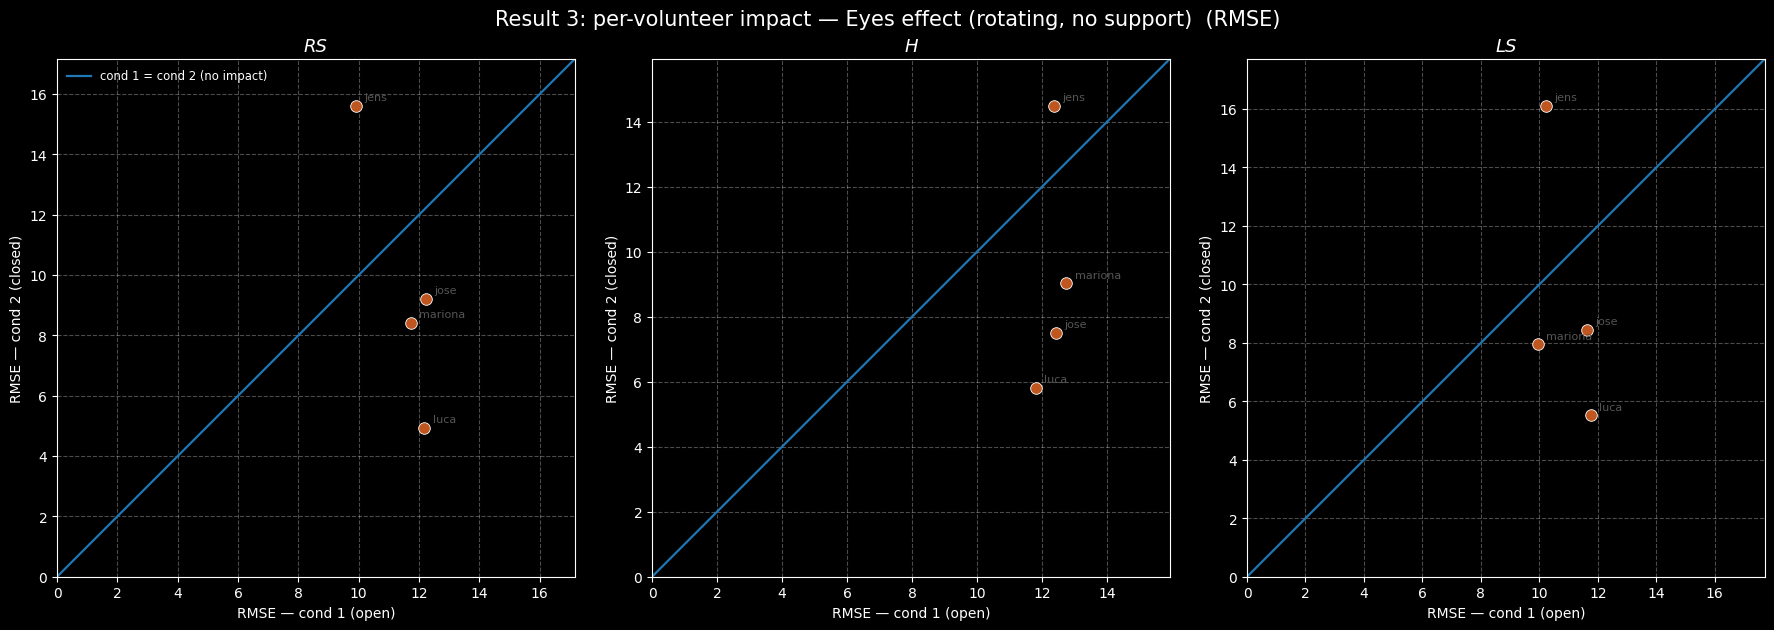

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/impact_Eyes_effect_rotating_no_support_RMSE.png


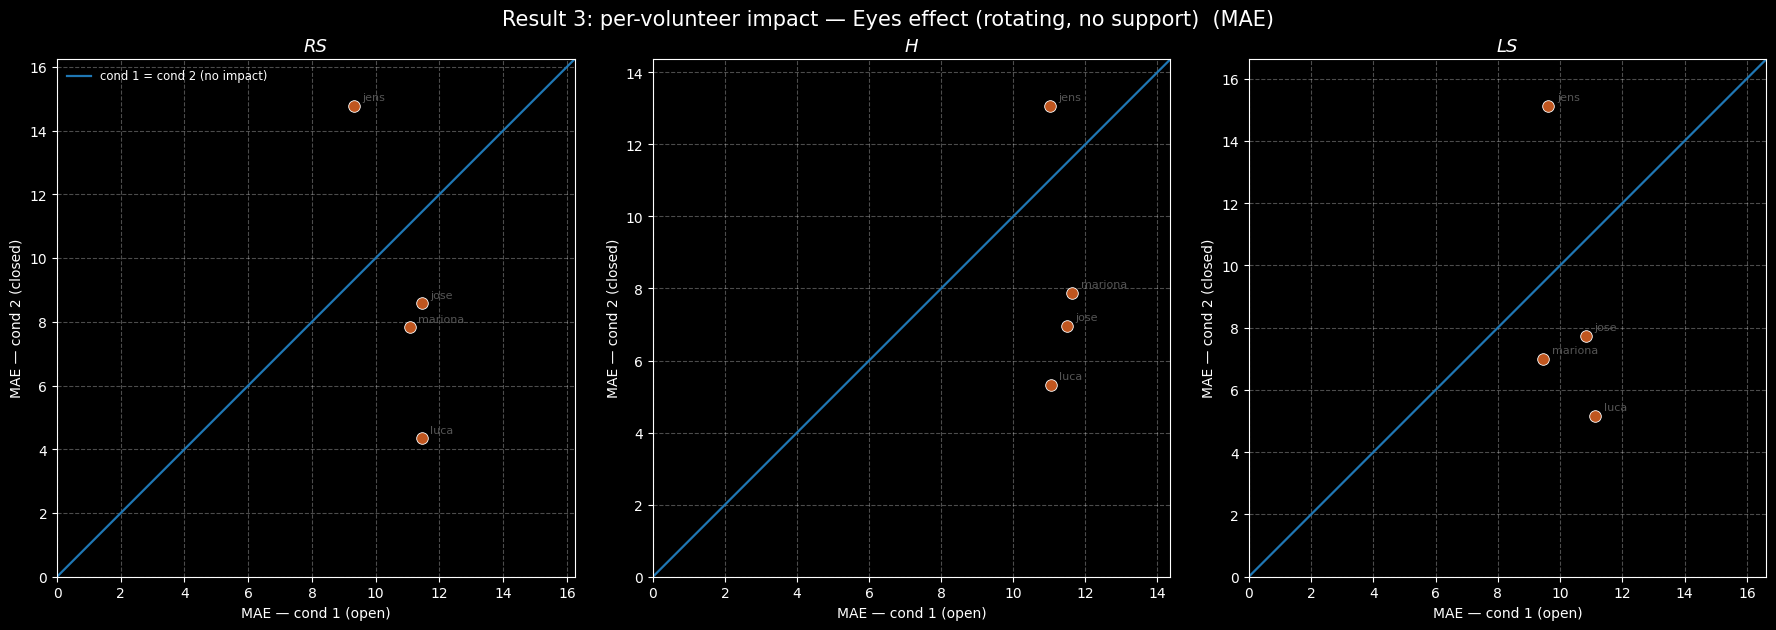

saved: /Volumes/Bapje_boris/Mariona/RecordingsMariona/MotionProfiles/impact_Eyes_effect_rotating_no_support_MAE.png


In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
base_dir = "/Volumes/Bapje_boris/Mariona/RecordingsMariona"
participants = ["jose", "jens", "mariona", "luca"]  # add "ann" / others if available
output_folder = os.path.join(base_dir, "MotionProfiles")
os.makedirs(output_folder, exist_ok=True)

trim = 30
metric_names = ["RMSE", "MAE"]  # a scatter is produced for each
annotate_names = True  # label each dot with the volunteer name

# --- map each position to its marker column(s). EDIT to your real layout. ---
positions = {
    "RS": ["pt1", "pt2"],
    "H": ["pt3", "pt4"],
    "LS": ["pt5", "pt6"],
}
axes_letters = ["x", "y", "z"]

# trial labels (for axis text)
trial_label = {
    1: "rotating, support, open",
    2: "rotating, support, closed",
    3: "rotating, no support, open",
    4: "rotating, no support, closed",
    5: "static, support",
    6: "static, no support",
}

# --- which condition pairs to compare (keep everything else constant) ---
# each entry: (title, trial_cond1, label_cond1, trial_cond2, label_cond2)
comparisons = [
    ("Support effect (rotating, closed)", 4, "no support", 2, "support"),
    ("Support effect (rotating, open)", 3, "no support", 1, "support"),
    ("Eyes effect (rotating, no support)", 3, "open", 4, "closed"),
]

DOT_COLOR = "#c0561f"
LINE_COLOR = "#1f77b4"


# -------------------------
# PER VOLUNTEER + TRIAL -> scalar RMSE / MAE of d(t) per position
# -------------------------
def metrics_for(participant, trial):
    path = os.path.join(
        base_dir, f"{participant}{trial}", "Output_processed", "transform_3d.csv"
    )
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if len(df) <= 2 * trim:
        return None
    df = df.iloc[trim:-trim].reset_index(drop=True)

    out = {}
    for pos, prefixes in positions.items():
        coords = {}
        for ax in axes_letters:
            sig = df[[f"{p}_{ax}" for p in prefixes]].mean(axis=1)
            coords[ax] = (sig - sig.mean()).to_numpy()
        d = np.sqrt(coords["x"] ** 2 + coords["y"] ** 2 + coords["z"] ** 2)
        out[pos] = {"RMSE": float(np.sqrt(np.mean(d ** 2))),
                    "MAE": float(np.mean(d))}
    return out


# M[trial][participant][pos][metric]
M = {}
for trial in trial_label:
    M[trial] = {}
    for p in participants:
        res = metrics_for(p, trial)
        if res is not None:
            M[trial][p] = res

# -------------------------
# SCATTER: one figure per (comparison, metric); 3 panels (RS, H, LS)
# x = metric in condition 1, y = metric in condition 2, one dot per volunteer
# -------------------------
pos_list = list(positions.keys())

for title, t1, lab1, t2, lab2 in comparisons:
    for metric in metric_names:
        fig, axarr = plt.subplots(1, 3, figsize=(18, 6))
        if len(pos_list) == 1:
            axarr = [axarr]

        for c, pos in enumerate(pos_list):
            ax = axarr[c]
            xs, ys, names = [], [], []
            for p in participants:
                if p in M[t1] and p in M[t2]:
                    xs.append(M[t1][p][pos][metric])
                    ys.append(M[t2][p][pos][metric])
                    names.append(p)

            if xs:
                ax.scatter(xs, ys, color=DOT_COLOR, s=70, zorder=3,
                           edgecolor="white", linewidth=0.6)
                if annotate_names:
                    for xv, yv, nm in zip(xs, ys, names):
                        ax.annotate(nm, (xv, yv), textcoords="offset points",
                                    xytext=(6, 4), fontsize=8, color="#555")

            # identity line (RMSE1 = RMSE2 -> no impact of intervention)
            hi = max(xs + ys) * 1.1 if xs else 1.0
            ax.plot([0, hi], [0, hi], color=LINE_COLOR, linewidth=1.6,
                    label="cond 1 = cond 2 (no impact)")
            ax.set_xlim(0, hi)
            ax.set_ylim(0, hi)
            ax.set_aspect("equal", adjustable="box")

            ax.set_title(pos, fontstyle="italic", fontsize=13)
            ax.set_xlabel(f"{metric} \u2014 cond 1 ({lab1})")
            ax.set_ylabel(f"{metric} \u2014 cond 2 ({lab2})")
            ax.grid(True, linestyle="--", alpha=0.3)
            if c == 0:
                ax.legend(loc="upper left", fontsize="small", frameon=False)

        fig.suptitle(f"Result 3: per-volunteer impact \u2014 {title}  ({metric})",
                     fontsize=15, y=1.0)
        plt.tight_layout()

        safe = title.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
        save_path = os.path.join(output_folder, f"impact_{safe}_{metric}.png")
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("saved:", save_path)

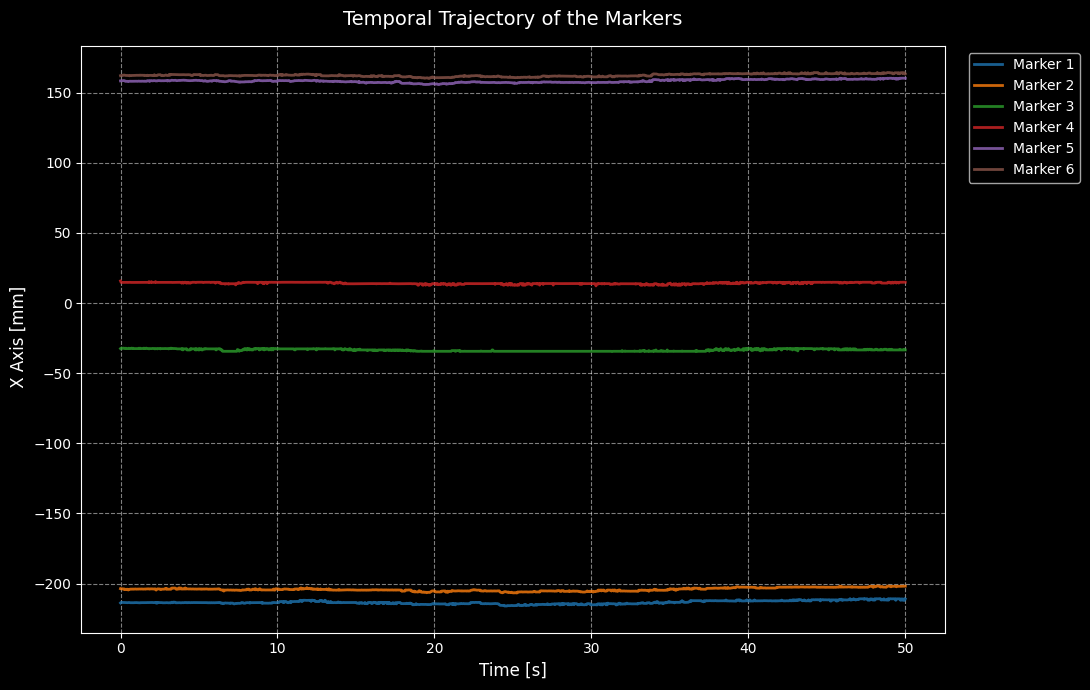

In [56]:
 import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/jose2/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(0, 50, num_points)
marker_prefixes = ["pt1", "pt2", "pt3", "pt4", "pt5", "pt6"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# -------------------------
# CREATE PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(11, 7))

for j, prefix in enumerate(marker_prefixes):
    x_coords = raw_df[f"{prefix}_x"]
    ax.plot(t, x_coords, label=f"Marker {j+1}", color=colors[j], linewidth=2, alpha=0.8,)


ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylabel(" X Axis [mm]", fontsize=12)
ax.set_title( "Temporal Trajectory of the Markers", fontsize=14, pad=15)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="medium")

plt.tight_layout()

plt.savefig(save_path, dpi=200)
plt.show()

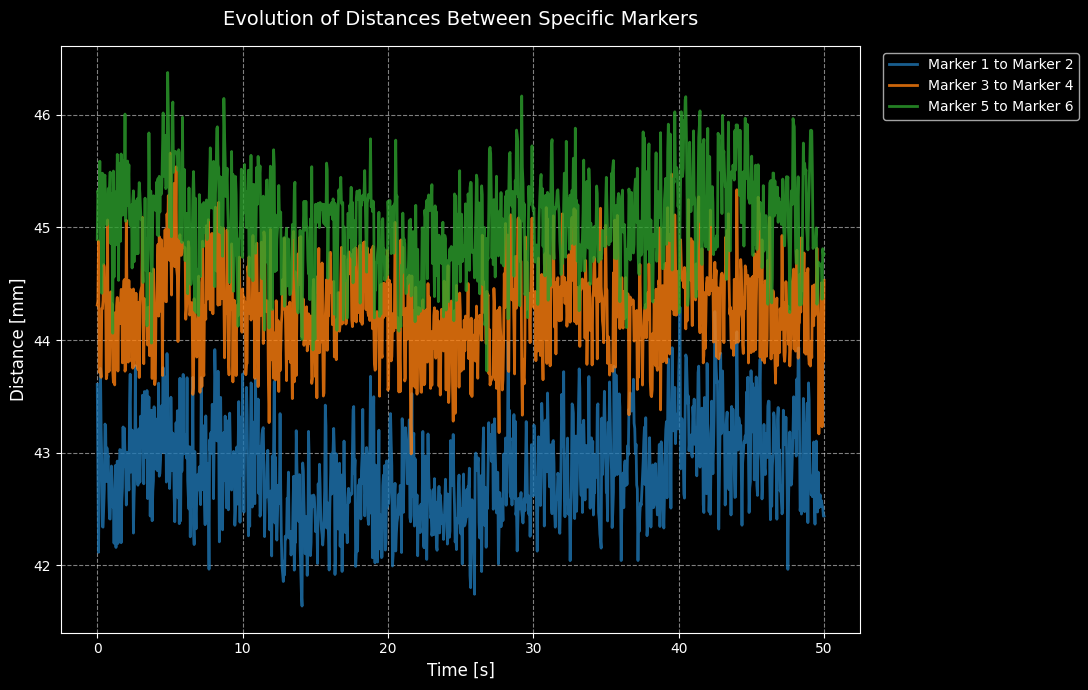

In [58]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

input_csv = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed/transform_3d.csv"
output_folder = "/Volumes/Bapje_boris/Mariona/RecordingsMariona/mariona4/Output_processed"

os.makedirs(output_folder, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
raw_df = pd.read_csv(input_csv)
raw_df = raw_df.iloc[20:-20].reset_index(drop=True)

num_points = raw_df.shape[0]
t = np.linspace(0, 50, num_points)

# Function to calculate 3D Euclidean distance between two markers
def calculate_distance(df, marker_a, marker_b):
    dx = df[f"{marker_a}_x"] - df[f"{marker_b}_x"]
    dy = df[f"{marker_a}_y"] - df[f"{marker_b}_y"]
    dz = df[f"{marker_a}_z"] - df[f"{marker_b}_z"]
    return np.sqrt(dx ** 2 + dy ** 2 + dz ** 2)

# -------------------------
# CALCULATE DISTANCES
# -------------------------
dist_1_2 = calculate_distance(raw_df, "pt1", "pt2")
dist_3_6 = calculate_distance(raw_df, "pt3", "pt4")
dist_4_5 = calculate_distance(raw_df, "pt5", "pt6")

# -------------------------
# CREATE PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(t, dist_1_2, label="Marker 1 to Marker 2", color="#1f77b4", linewidth=2, alpha=0.8)
ax.plot(t, dist_3_6, label="Marker 3 to Marker 4", color="#ff7f0e", linewidth=2, alpha=0.8)
ax.plot(t, dist_4_5, label="Marker 5 to Marker 6", color="#2ca02c", linewidth=2, alpha=0.8)

ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylabel("Distance [mm]", fontsize=12)
ax.set_title("Evolution of Distances Between Specific Markers", fontsize=14, pad=15)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize="medium")

plt.tight_layout()
plt.savefig(save_path, dpi=200)
plt.show()